Dataset downloaded successfully.


,Check,Result
0,Original hourly rows,50401
1,Invalid timestamps,0
2,Duplicate timestamps,0
3,Missing hours before treatment,0
4,Missing values after treatment,0
5,Complete daily observations,2100
6,Complete weekly observations,299
7,Weekly training observations,195
8,Weekly testing observations,104


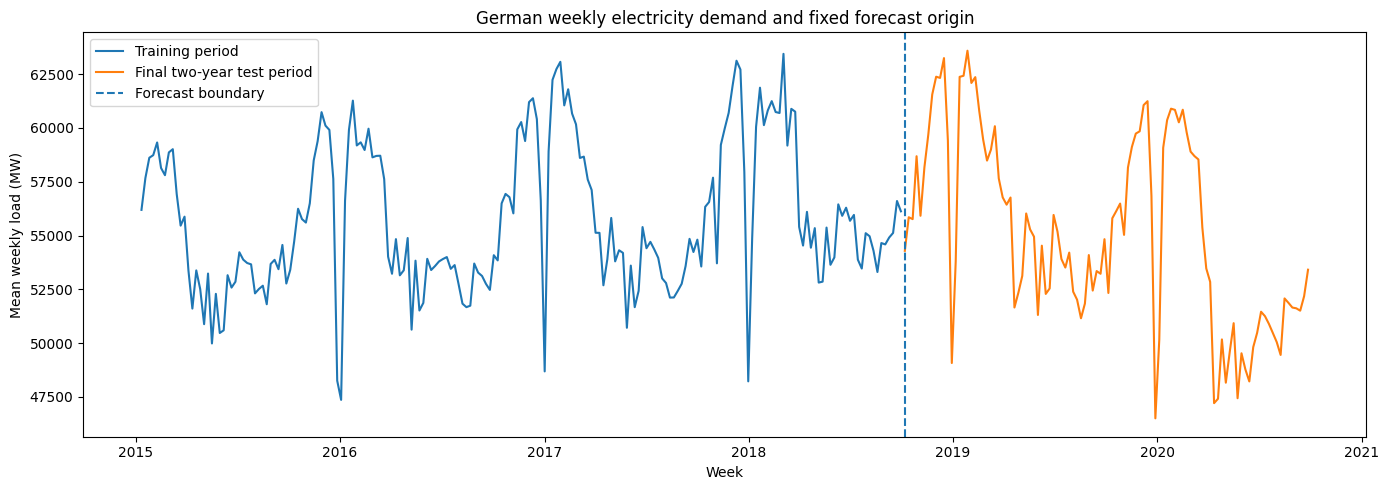

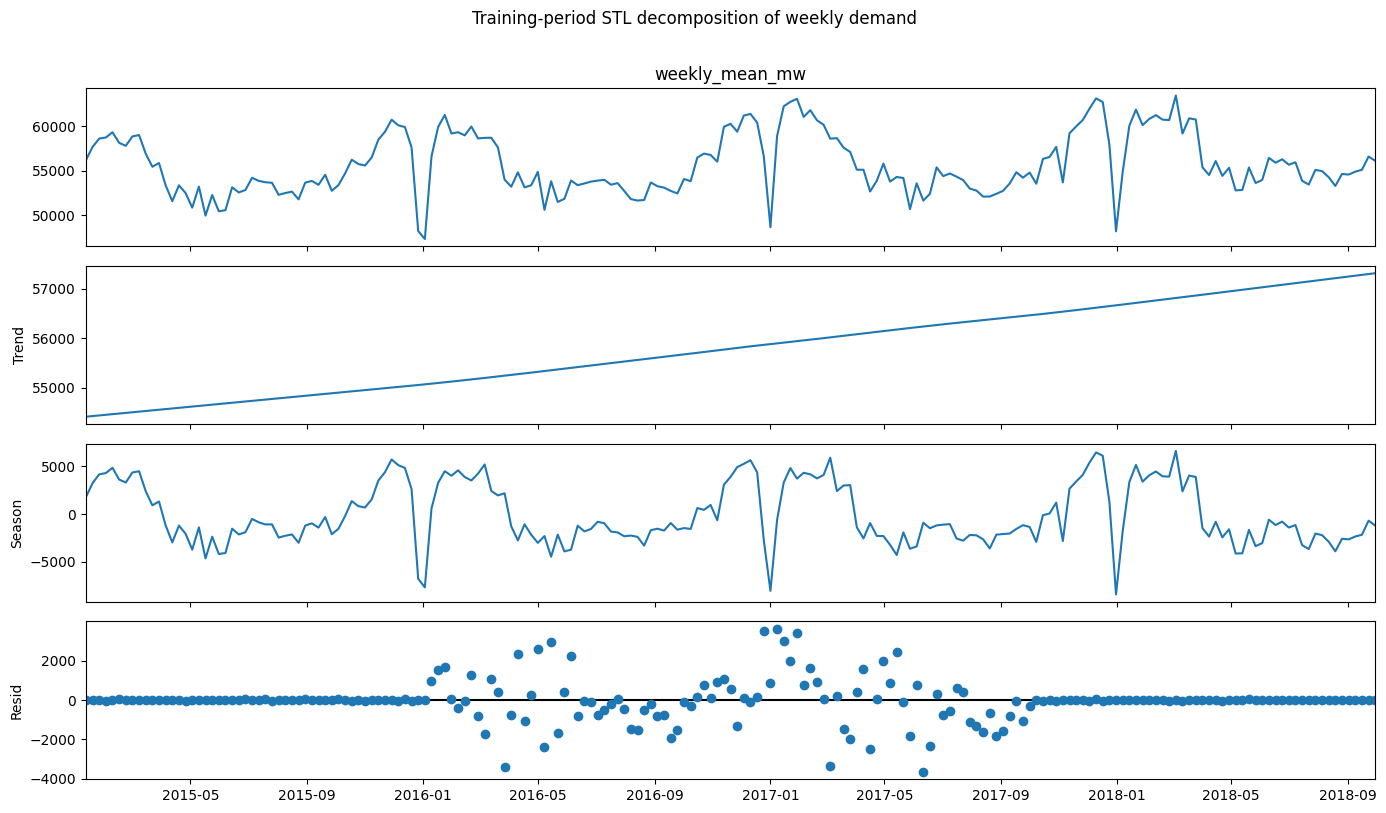

,Series,ADF_statistic,ADF_pvalue,KPSS_statistic,KPSS_pvalue
0,Original weekly training series,-5.0030,0.0,0.1499,0.1
1,First difference,-5.5708,0.0,0.0406,0.1
2,Seasonal difference at lag 52,-5.0395,0.0,0.0910,0.1
3,First plus seasonal difference,-6.7279,0.0,0.0138,0.1


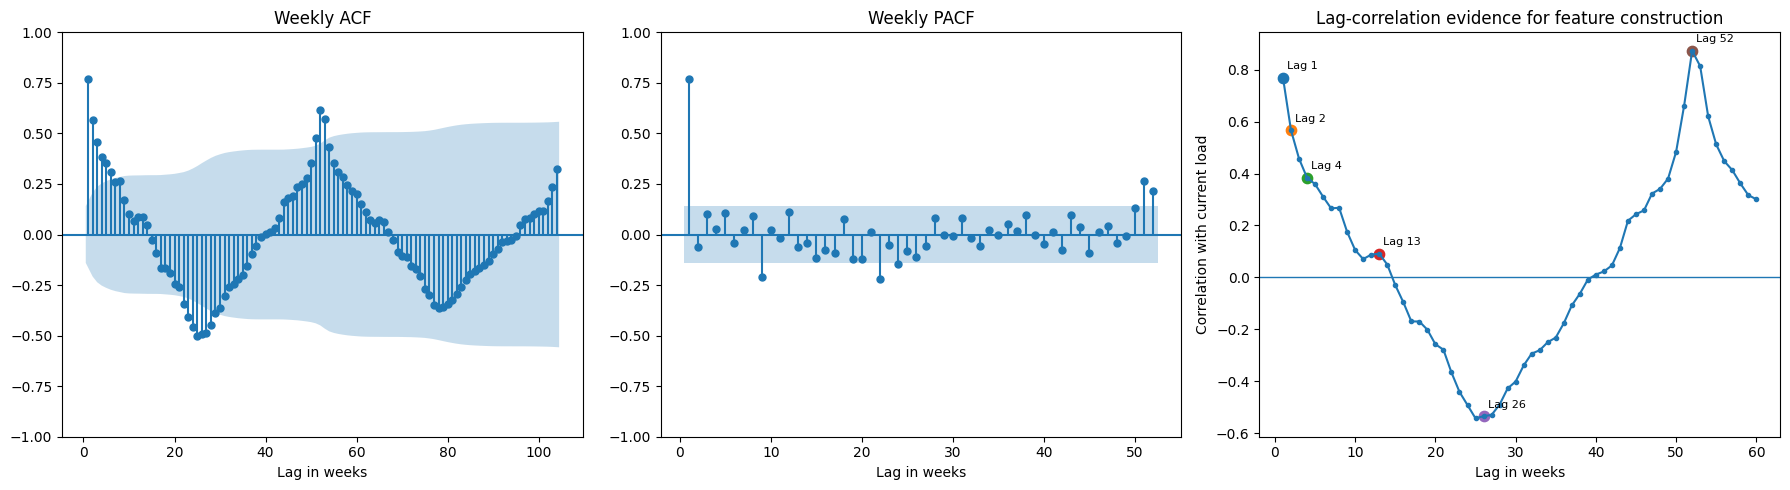

Cell 1 completed: 50400 hourly observations, 2100 daily observations and 299 complete weekly observations.


In [1]:
# ============================================================
# CELL 1: DATA PREPARATION, FOCUSED EDA AND STATIONARITY
# ============================================================
# This cell completes Assignment Part 1:
# - Downloads German hourly electricity load
# - Keeps data from 1 January 2015 onward
# - Checks timestamps, duplicates and missing values
# - Creates hourly, daily and weekly mean-load series
# - Reserves the final 104 complete weeks for testing
# - Performs focused EDA
# - Runs ADF and KPSS stationarity tests
# - Applies first and seasonal differencing
# - Produces ACF, PACF and lag-correlation evidence
#
# Three essential figures are created:
# 1. Weekly load and forecast boundary
# 2. STL decomposition
# 3. ACF, PACF and lag-correlation profile
# ============================================================

import sys
import subprocess
import warnings
import time
import itertools
import ast
from pathlib import Path

try:
    import holidays
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "holidays"
    ])
    import holidays

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import display
from scipy import stats

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.stattools import (
    adfuller,
    kpss
)
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_URL = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)

TIME_COLUMN = "utc_timestamp"
LOAD_COLUMN = "DE_load_actual_entsoe_transparency"

START_DATE = "2015-01-01"

# Weeks end on Sunday.
WEEK_FREQUENCY = "W-SUN"

# Final two years = 104 complete weeks.
TEST_WEEKS = 104

# Annual weekly seasonal period.
SEASON_LENGTH = 52

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_DIR / "cache"

for folder in [
    DATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    CACHE_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


def save_figure(filename):
    """Save the current figure at report quality."""

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def calculate_smape(actual, predicted):
    """Calculate symmetric mean absolute percentage error."""

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    denominator = (
        np.abs(actual)
        + np.abs(predicted)
    )

    errors = np.where(
        denominator == 0,
        0,
        2 * np.abs(actual - predicted) / denominator
    )

    return 100 * np.mean(errors)


def calculate_mase(
    actual,
    predicted,
    training_series,
    season_length=52
):
    """
    Calculate Mean Absolute Scaled Error using an
    in-sample seasonal-naive scaling error.
    """

    training_values = np.asarray(
        training_series,
        dtype=float
    )

    scale = np.mean(
        np.abs(
            training_values[season_length:]
            - training_values[:-season_length]
        )
    )

    return (
        np.mean(
            np.abs(
                np.asarray(actual)
                - np.asarray(predicted)
            )
        )
        / scale
    )


def calculate_bias(actual, predicted):
    """
    Calculate mean signed error.

    Positive bias:
        Average underprediction.

    Negative bias:
        Average overprediction.
    """

    return np.mean(
        np.asarray(actual)
        - np.asarray(predicted)
    )


def evaluate_forecast(
    actual,
    predicted,
    training_series
):
    """Evaluate a forecast using common weekly metrics."""

    prediction_series = pd.Series(
        np.asarray(predicted, dtype=float),
        index=actual.index
    )

    return {
        "MAE": mean_absolute_error(
            actual,
            prediction_series
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                prediction_series
            )
        ),

        "sMAPE_percent": calculate_smape(
            actual,
            prediction_series
        ),

        "MASE": calculate_mase(
            actual,
            prediction_series,
            training_series,
            SEASON_LENGTH
        ),

        "Bias": calculate_bias(
            actual,
            prediction_series
        )
    }


# ------------------------------------------------------------
# DOWNLOAD AND CACHE THE LARGE CSV FILE
# ------------------------------------------------------------

electricity_file = (
    DATA_DIR
    / "time_series_60min_singleindex.csv"
)

if not electricity_file.exists():

    print("Downloading the electricity dataset...")

    with requests.get(
        DATA_URL,
        stream=True,
        timeout=180
    ) as response:

        response.raise_for_status()

        with open(
            electricity_file,
            "wb"
        ) as output_file:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):

                if chunk:
                    output_file.write(chunk)

    print("Dataset downloaded successfully.")

else:
    print("Using the cached electricity dataset.")


# ------------------------------------------------------------
# LOAD ONLY THE REQUIRED GERMAN COLUMNS
# ------------------------------------------------------------

raw_data = pd.read_csv(
    electricity_file,
    usecols=[
        TIME_COLUMN,
        LOAD_COLUMN
    ]
)

original_rows = len(raw_data)

raw_data[TIME_COLUMN] = pd.to_datetime(
    raw_data[TIME_COLUMN],
    utc=True,
    errors="coerce"
)

raw_data[LOAD_COLUMN] = pd.to_numeric(
    raw_data[LOAD_COLUMN],
    errors="coerce"
)

invalid_timestamps = int(
    raw_data[TIME_COLUMN]
    .isna()
    .sum()
)

duplicate_timestamps = int(
    raw_data[TIME_COLUMN]
    .duplicated()
    .sum()
)

raw_data = (
    raw_data
    .dropna(subset=[TIME_COLUMN])
    .drop_duplicates(subset=[TIME_COLUMN])
    .sort_values(TIME_COLUMN)
    .set_index(TIME_COLUMN)
)


# ------------------------------------------------------------
# CREATE A REGULAR HOURLY LOAD SERIES
# ------------------------------------------------------------

hourly_load = (
    raw_data
    .loc[START_DATE:, LOAD_COLUMN]
    .rename("load_mw")
    .astype(float)
)

complete_hourly_index = pd.date_range(
    start=hourly_load.index.min().floor("h"),
    end=hourly_load.index.max().floor("h"),
    freq="h",
    tz="UTC"
)

hourly_load = hourly_load.reindex(
    complete_hourly_index
)

hourly_load.index.name = "timestamp"

missing_before = int(
    hourly_load.isna().sum()
)

# Treat short interruptions first.
hourly_load = hourly_load.interpolate(
    method="time",
    limit=3,
    limit_direction="both"
)

# Resolve any remaining gaps so all models receive
# a continuous hourly series.
if hourly_load.isna().any():

    print(
        "Longer gaps remained after short-gap treatment. "
        "Time interpolation was applied to complete the series."
    )

    hourly_load = (
        hourly_load
        .interpolate(
            method="time",
            limit_direction="both"
        )
        .ffill()
        .bfill()
    )

missing_after = int(
    hourly_load.isna().sum()
)


# ------------------------------------------------------------
# CREATE DAILY AND WEEKLY MEAN LOAD
# ------------------------------------------------------------

daily_counts = (
    hourly_load
    .resample("D")
    .count()
)

daily_load = (
    hourly_load
    .resample("D")
    .mean()
)

# Keep complete UTC days.
daily_load = daily_load[
    daily_counts == 24
].rename(
    "daily_mean_mw"
)


weekly_counts = (
    hourly_load
    .resample(WEEK_FREQUENCY)
    .count()
)

weekly_load = (
    hourly_load
    .resample(WEEK_FREQUENCY)
    .mean()
)

# Keep complete 168-hour weeks only.
weekly_load = weekly_load[
    weekly_counts == 168
].rename(
    "weekly_mean_mw"
)


# ------------------------------------------------------------
# CREATE THE FIXED TWO-YEAR TEST PERIOD
# ------------------------------------------------------------

weekly_train = weekly_load.iloc[
    :-TEST_WEEKS
].copy()

weekly_test = weekly_load.iloc[
    -TEST_WEEKS:
].copy()

if len(weekly_test) != TEST_WEEKS:
    raise ValueError(
        "The weekly test period does not contain 104 weeks."
    )

if len(weekly_train) < 2 * SEASON_LENGTH:
    raise ValueError(
        "Insufficient training history for annual seasonality."
    )

weekly_predictions = {}


# ------------------------------------------------------------
# DISPLAY DATA-QUALITY EVIDENCE
# ------------------------------------------------------------

data_quality_table = pd.DataFrame({
    "Check": [
        "Original hourly rows",
        "Invalid timestamps",
        "Duplicate timestamps",
        "Missing hours before treatment",
        "Missing values after treatment",
        "Complete daily observations",
        "Complete weekly observations",
        "Weekly training observations",
        "Weekly testing observations"
    ],

    "Result": [
        original_rows,
        invalid_timestamps,
        duplicate_timestamps,
        missing_before,
        missing_after,
        len(daily_load),
        len(weekly_load),
        len(weekly_train),
        len(weekly_test)
    ]
})

display(data_quality_table)

data_quality_table.to_csv(
    TABLE_DIR / "data_quality_table.csv",
    index=False
)


# ------------------------------------------------------------
# FIGURE 1: WEEKLY LOAD AND FORECAST ORIGIN
# ------------------------------------------------------------

fig, axis = plt.subplots(
    figsize=(14, 5)
)

axis.plot(
    weekly_train.index,
    weekly_train,
    label="Training period"
)

axis.plot(
    weekly_test.index,
    weekly_test,
    label="Final two-year test period"
)

axis.axvline(
    weekly_test.index.min(),
    linestyle="--",
    linewidth=1.5,
    label="Forecast boundary"
)

axis.set_title(
    "German weekly electricity demand and fixed forecast origin"
)

axis.set_xlabel("Week")
axis.set_ylabel("Mean weekly load (MW)")
axis.legend()

save_figure(
    "01_weekly_load_and_forecast_boundary.png"
)


# ------------------------------------------------------------
# FIGURE 2: TRAINING-PERIOD STL DECOMPOSITION
# ------------------------------------------------------------

stl_result = STL(
    weekly_train,
    period=SEASON_LENGTH,
    robust=True
).fit()

stl_figure = stl_result.plot()

stl_figure.set_size_inches(
    14,
    8
)

stl_figure.suptitle(
    "Training-period STL decomposition of weekly demand",
    y=1.01
)

save_figure(
    "02_weekly_stl_decomposition.png"
)


# ------------------------------------------------------------
# STATIONARITY TESTS
# ------------------------------------------------------------

def run_stationarity_tests(
    series,
    series_name
):
    """Run complementary ADF and KPSS tests."""

    clean_series = (
        pd.Series(series)
        .dropna()
        .astype(float)
    )

    adf_result = adfuller(
        clean_series,
        autolag="AIC"
    )

    try:
        kpss_result = kpss(
            clean_series,
            regression="c",
            nlags="auto"
        )

        kpss_statistic = kpss_result[0]
        kpss_pvalue = kpss_result[1]

    except Exception:
        kpss_statistic = np.nan
        kpss_pvalue = np.nan

    return {
        "Series": series_name,
        "ADF_statistic": adf_result[0],
        "ADF_pvalue": adf_result[1],
        "KPSS_statistic": kpss_statistic,
        "KPSS_pvalue": kpss_pvalue
    }


weekly_first_difference = (
    weekly_train
    .diff()
)

weekly_seasonal_difference = (
    weekly_train
    .diff(SEASON_LENGTH)
)

weekly_combined_difference = (
    weekly_train
    .diff()
    .diff(SEASON_LENGTH)
)

stationarity_table = pd.DataFrame([
    run_stationarity_tests(
        weekly_train,
        "Original weekly training series"
    ),

    run_stationarity_tests(
        weekly_first_difference,
        "First difference"
    ),

    run_stationarity_tests(
        weekly_seasonal_difference,
        "Seasonal difference at lag 52"
    ),

    run_stationarity_tests(
        weekly_combined_difference,
        "First plus seasonal difference"
    )
])

display(
    stationarity_table.round(4)
)

stationarity_table.to_csv(
    TABLE_DIR / "stationarity_results.csv",
    index=False
)


# ------------------------------------------------------------
# FIGURE 3: ACF, PACF AND LAG-CORRELATION PROFILE
# ------------------------------------------------------------

maximum_lag = 60

lag_correlations = pd.Series({
    lag: weekly_train.corr(
        weekly_train.shift(lag)
    )

    for lag in range(
        1,
        maximum_lag + 1
    )
})

selected_lags = [
    1,
    2,
    4,
    13,
    26,
    52
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

plot_acf(
    weekly_train,
    lags=104,
    fft=True,
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    "Weekly ACF"
)

axes[0].set_xlabel(
    "Lag in weeks"
)

plot_pacf(
    weekly_train,
    lags=52,
    method="ywm",
    zero=False,
    ax=axes[1]
)

axes[1].set_title(
    "Weekly PACF"
)

axes[1].set_xlabel(
    "Lag in weeks"
)

axes[2].plot(
    lag_correlations.index,
    lag_correlations.values,
    marker="o",
    markersize=3
)

for lag in selected_lags:

    axes[2].scatter(
        lag,
        lag_correlations.loc[lag],
        s=55
    )

    axes[2].annotate(
        f"Lag {lag}",
        (
            lag,
            lag_correlations.loc[lag]
        ),
        xytext=(3, 6),
        textcoords="offset points",
        fontsize=8
    )

axes[2].axhline(
    0,
    linewidth=1
)

axes[2].set_title(
    "Lag-correlation evidence for feature construction"
)

axes[2].set_xlabel(
    "Lag in weeks"
)

axes[2].set_ylabel(
    "Correlation with current load"
)

save_figure(
    "03_acf_pacf_and_lag_correlation.png"
)

print(
    "Cell 1 completed:",
    len(hourly_load),
    "hourly observations,",
    len(daily_load),
    "daily observations and",
    len(weekly_load),
    "complete weekly observations."
)

In [2]:
# ============================================================
# CELL 2: WEEKLY BENCHMARK FORECASTING MODELS
# ============================================================
# This cell completes Assignment Part 2:
# - Mean forecast
# - Naive forecast
# - Seasonal Naive forecast
# - Drift forecast
# - Final 104-week forecast horizon
# - Common evaluation metrics
#
# Seasonal Naive is retained as the main benchmark.
# No plot is created because all models appear in Cell 8.
# ============================================================

def mean_forecast(
    training_series,
    forecast_index
):
    """Forecast every week using the training mean."""

    return pd.Series(
        training_series.mean(),
        index=forecast_index
    )


def naive_forecast(
    training_series,
    forecast_index
):
    """Forecast every week using the final training value."""

    return pd.Series(
        training_series.iloc[-1],
        index=forecast_index
    )


def seasonal_naive_forecast(
    training_series,
    forecast_index,
    season_length=52
):
    """
    Repeat the latest annual sequence of weekly values.
    """

    latest_annual_pattern = (
        training_series
        .iloc[-season_length:]
        .to_numpy()
    )

    repeated_pattern = np.resize(
        latest_annual_pattern,
        len(forecast_index)
    )

    return pd.Series(
        repeated_pattern,
        index=forecast_index
    )


def drift_forecast(
    training_series,
    forecast_index
):
    """
    Continue the average change between the first
    and final training observations.
    """

    slope = (
        training_series.iloc[-1]
        - training_series.iloc[0]
    ) / (
        len(training_series) - 1
    )

    steps = np.arange(
        1,
        len(forecast_index) + 1
    )

    forecast_values = (
        training_series.iloc[-1]
        + slope * steps
    )

    return pd.Series(
        forecast_values,
        index=forecast_index
    )


benchmark_predictions = {
    "Mean": mean_forecast(
        weekly_train,
        weekly_test.index
    ),

    "Naive": naive_forecast(
        weekly_train,
        weekly_test.index
    ),

    "Seasonal Naive": seasonal_naive_forecast(
        weekly_train,
        weekly_test.index,
        SEASON_LENGTH
    ),

    "Drift": drift_forecast(
        weekly_train,
        weekly_test.index
    )
}

weekly_predictions.update(
    benchmark_predictions
)

benchmark_metrics = pd.DataFrame({
    model_name: evaluate_forecast(
        weekly_test,
        model_prediction,
        weekly_train
    )

    for model_name, model_prediction
    in benchmark_predictions.items()
}).T

benchmark_metrics = (
    benchmark_metrics
    .sort_values("RMSE")
)

display(
    benchmark_metrics.round(3)
)

benchmark_metrics.to_csv(
    TABLE_DIR / "benchmark_metrics.csv"
)

print(
    "Principal benchmark:",
    "Seasonal Naive"
)

print(
    "Seasonal Naive RMSE:",
    round(
        benchmark_metrics.loc[
            "Seasonal Naive",
            "RMSE"
        ],
        3
    )
)

,MAE,RMSE,sMAPE_percent,MASE,Bias
Seasonal Naive,2288.489,2988.248,4.207,1.694,-1747.805
Mean,3789.845,4402.059,6.874,2.805,-561.192
Drift,3850.776,4466.494,6.982,2.850,-966.386
Naive,3858.148,4475.767,6.995,2.856,-984.534


Principal benchmark: Seasonal Naive
Seasonal Naive RMSE: 2988.248


Required p,d,q combinations: 147
Completed 10 of 147 required combinations.
Completed 20 of 147 required combinations.
Completed 30 of 147 required combinations.
Completed 40 of 147 required combinations.
Completed 50 of 147 required combinations.
Completed 60 of 147 required combinations.
Completed 70 of 147 required combinations.
Completed 80 of 147 required combinations.
Completed 90 of 147 required combinations.
Completed 100 of 147 required combinations.
Completed 110 of 147 required combinations.
Completed 120 of 147 required combinations.
Completed 130 of 147 required combinations.
Completed 140 of 147 required combinations.


,order,seasonal_order,AIC,BIC,converged,runtime_seconds,error
71,"(3, 1, 1)","(0, 1, 1, 52)",2271.457271,2286.321292,True,1.353377,
8,"(0, 1, 1)","(0, 1, 1, 52)",2292.304021,2299.736031,True,0.459484,
16,"(0, 2, 2)","(0, 1, 1, 52)",2307.091964,2316.909353,True,1.465713,
9,"(0, 1, 2)","(0, 1, 1, 52)",2312.311836,2322.175468,True,0.577344,
11,"(0, 1, 4)","(0, 1, 1, 52)",2314.150797,2328.806704,True,1.393399,
12,"(0, 1, 5)","(0, 1, 1, 52)",2314.623109,2331.638827,True,1.827456,
10,"(0, 1, 3)","(0, 1, 1, 52)",2319.701953,2331.973689,True,0.767709,
57,"(2, 2, 1)","(0, 1, 1, 52)",2323.475014,2335.804554,True,0.921532,
99,"(4, 2, 1)","(0, 1, 1, 52)",2324.276502,2341.537859,True,1.599394,
120,"(5, 2, 1)","(0, 1, 1, 52)",2324.409238,2344.136503,True,4.497455,


,order,seasonal_order,AIC,BIC,converged,runtime_seconds,error
2,"(3, 1, 1)","(0, 1, 1, 52)",2271.457271,2286.321292,True,1.432497,
3,"(3, 1, 1)","(1, 1, 1, 52)",2271.806864,2289.068221,True,5.007763,
7,"(0, 1, 1)","(1, 1, 1, 52)",2281.624595,2291.533942,True,0.746151,
15,"(0, 1, 2)","(1, 1, 1, 52)",2281.974128,2294.303669,True,1.054755,
11,"(0, 2, 2)","(1, 1, 1, 52)",2283.347256,2295.618992,True,2.324670,
6,"(0, 1, 1)","(0, 1, 1, 52)",2292.304021,2299.736031,True,0.544777,
19,"(0, 1, 4)","(1, 1, 1, 52)",2292.381406,2309.479965,True,1.810798,
10,"(0, 2, 2)","(0, 1, 1, 52)",2307.091964,2316.909353,True,0.818215,
14,"(0, 1, 2)","(0, 1, 1, 52)",2312.311836,2322.175468,True,0.622771,
18,"(0, 1, 4)","(0, 1, 1, 52)",2314.150797,2328.806704,True,3.790421,


Selected SARIMA order: (3, 1, 1)
Selected seasonal order: (0, 1, 1, 52)
Final SARIMA AIC: 1547.263


,lb_stat,lb_pvalue
12,1.200749,0.999961
26,4.411263,0.999999
52,46.551143,0.687288


,Residual_mean,Residual_standard_deviation,Residual_skewness,Residual_kurtosis
0,-88.11,4866.8,6.957,98.499


,MAE,RMSE,sMAPE_percent,MASE,Bias,Interval_coverage_percent
SARIMA,3177.99,3912.954,5.758,2.352,-2994.145,74.038


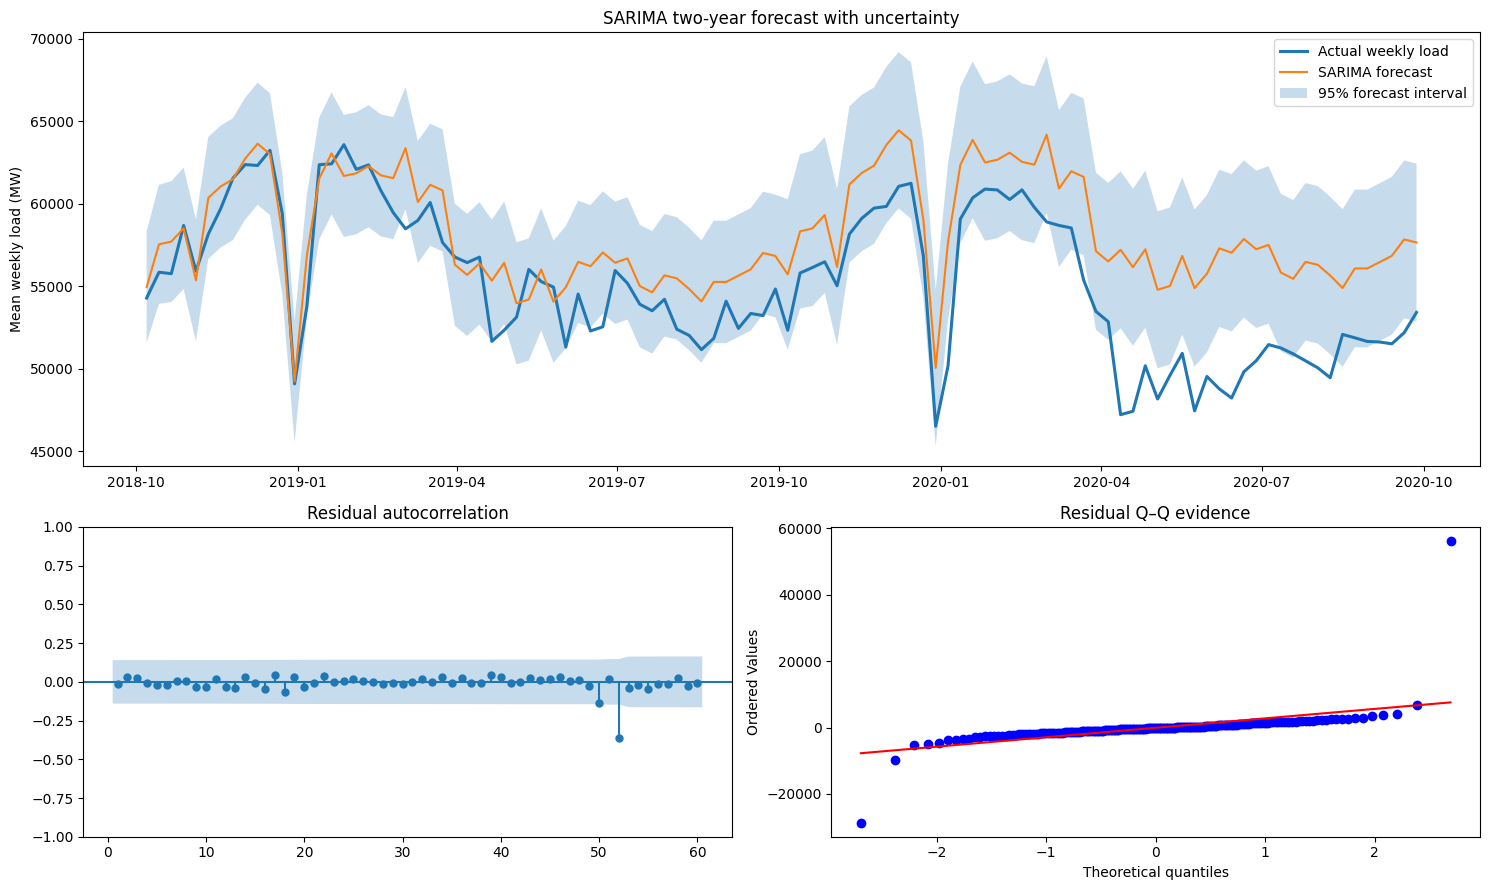

In [3]:
# ============================================================
# CELL 3: SARIMA PARAMETER SEARCH, DIAGNOSTICS AND FORECAST
# ============================================================
# This cell completes Assignment Part 3:
# - Tests all 147 required p,d,q combinations
# - Uses AIC for model selection
# - Uses annual weekly seasonality s = 52
# - Refines the best candidates across a compact seasonal grid
# - Saves screening progress to avoid restarting
# - Fits the final SARIMA model
# - Inspects residual distribution and autocorrelation
# - Runs the Ljung-Box test
# - Forecasts the final 104 weeks
# - Adds a 95% confidence interval
# - Calculates forecast interval coverage
#
# One essential SARIMA figure is created.
# ============================================================

sarima_cache_file = (
    CACHE_DIR
    / "sarima_147_screening.csv"
)


def fit_sarima_candidate(
    order,
    seasonal_order,
    maximum_iterations=15
):
    """
    Fit one SARIMA candidate safely.

    Failed or non-converged models are recorded rather
    than stopping the complete parameter search.
    """

    fit_start = time.time()

    try:
        candidate_model = SARIMAX(
            weekly_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
            concentrate_scale=True,
            simple_differencing=True
        )

        candidate_result = candidate_model.fit(
            method="lbfgs",
            maxiter=maximum_iterations,
            disp=False,
            low_memory=True
        )

        return {
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "AIC": candidate_result.aic,
            "BIC": candidate_result.bic,

            "converged": bool(
                candidate_result
                .mle_retvals
                .get(
                    "converged",
                    False
                )
            ),

            "runtime_seconds": (
                time.time()
                - fit_start
            ),

            "error": ""
        }

    except Exception as model_error:

        return {
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "AIC": np.inf,
            "BIC": np.inf,
            "converged": False,

            "runtime_seconds": (
                time.time()
                - fit_start
            ),

            "error": str(model_error)[:180]
        }


# ------------------------------------------------------------
# REQUIRED 147 NON-SEASONAL COMBINATIONS
# ------------------------------------------------------------

required_orders = list(
    itertools.product(
        range(0, 7),
        range(0, 3),
        range(0, 7)
    )
)

print(
    "Required p,d,q combinations:",
    len(required_orders)
)

# One compact annual seasonal structure is used during
# the first screening stage.
screening_seasonal_order = (
    0,
    1,
    1,
    52
)


# ------------------------------------------------------------
# LOAD SAVED SEARCH PROGRESS
# ------------------------------------------------------------

if sarima_cache_file.exists():

    screening_results = pd.read_csv(
        sarima_cache_file
    )

    screening_results = (
        screening_results
        .drop_duplicates(
            subset="order",
            keep="last"
        )
    )

    completed_orders = set(
        screening_results[
            "order"
        ].astype(str)
    )

    screening_rows = (
        screening_results
        .to_dict("records")
    )

    print(
        "Loaded",
        len(completed_orders),
        "previous SARIMA fits."
    )

else:
    completed_orders = set()
    screening_rows = []


# ------------------------------------------------------------
# SCREEN EVERY REQUIRED p,d,q COMBINATION
# ------------------------------------------------------------

for order in required_orders:

    if str(order) in completed_orders:
        continue

    result_row = fit_sarima_candidate(
        order=order,
        seasonal_order=screening_seasonal_order,
        maximum_iterations=15
    )

    screening_rows.append(
        result_row
    )

    if len(screening_rows) % 10 == 0:

        pd.DataFrame(
            screening_rows
        ).to_csv(
            sarima_cache_file,
            index=False
        )

        print(
            f"Completed {len(screening_rows)} "
            "of 147 required combinations."
        )


screening_results = pd.DataFrame(
    screening_rows
)

screening_results = (
    screening_results
    .drop_duplicates(
        subset="order",
        keep="last"
    )
)

screening_results.to_csv(
    sarima_cache_file,
    index=False
)

if screening_results["order"].nunique() != 147:
    raise ValueError(
        "The complete set of 147 p,d,q combinations "
        "was not attempted."
    )


finite_screening = (
    screening_results[
        np.isfinite(
            screening_results["AIC"]
        )
    ]
    .copy()
)

converged_screening = finite_screening[
    finite_screening["converged"] == True
]

# Prefer converged candidates. Fall back to all finite
# candidates only when no model reports convergence.
screening_candidate_pool = (
    converged_screening
    if len(converged_screening) > 0
    else finite_screening
)

screening_candidate_pool = (
    screening_candidate_pool
    .sort_values("AIC")
)

display(
    screening_candidate_pool.head(10)
)


# ------------------------------------------------------------
# REFINE THE STRONGEST NON-SEASONAL CANDIDATES
# ------------------------------------------------------------

top_nonseasonal_orders = [
    ast.literal_eval(order_text)

    for order_text in (
        screening_candidate_pool
        .head(5)["order"]
    )
]

seasonal_refinement_grid = [
    (0, 0, 0, 52),
    (1, 0, 0, 52),
    (0, 1, 1, 52),
    (1, 1, 1, 52)
]

refinement_rows = []

for nonseasonal_order in top_nonseasonal_orders:

    for seasonal_order in seasonal_refinement_grid:

        refinement_rows.append(
            fit_sarima_candidate(
                order=nonseasonal_order,
                seasonal_order=seasonal_order,
                maximum_iterations=70
            )
        )


refinement_results = pd.DataFrame(
    refinement_rows
)

finite_refinement = refinement_results[
    np.isfinite(
        refinement_results["AIC"]
    )
]

converged_refinement = finite_refinement[
    finite_refinement["converged"] == True
]

refinement_candidate_pool = (
    converged_refinement
    if len(converged_refinement) > 0
    else finite_refinement
)

refinement_candidate_pool = (
    refinement_candidate_pool
    .sort_values("AIC")
)

display(
    refinement_candidate_pool.head(10)
)

refinement_candidate_pool.to_csv(
    TABLE_DIR / "sarima_refinement_results.csv",
    index=False
)


# ------------------------------------------------------------
# FIT THE FINAL MODEL WITH FALLBACK CANDIDATES
# ------------------------------------------------------------

final_sarima_result = None
best_sarima_order = None
best_sarima_seasonal_order = None

for _, candidate_row in (
    refinement_candidate_pool
    .head(5)
    .iterrows()
):

    candidate_order = ast.literal_eval(
        candidate_row["order"]
    )

    candidate_seasonal_order = ast.literal_eval(
        candidate_row["seasonal_order"]
    )

    try:
        final_model = SARIMAX(
            weekly_train,
            order=candidate_order,
            seasonal_order=candidate_seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_candidate = final_model.fit(
            method="lbfgs",
            maxiter=200,
            disp=False
        )

        final_sarima_result = fitted_candidate
        best_sarima_order = candidate_order
        best_sarima_seasonal_order = (
            candidate_seasonal_order
        )

        break

    except Exception:
        continue


if final_sarima_result is None:
    raise RuntimeError(
        "None of the refined SARIMA candidates "
        "could be fitted successfully."
    )

print(
    "Selected SARIMA order:",
    best_sarima_order
)

print(
    "Selected seasonal order:",
    best_sarima_seasonal_order
)

print(
    "Final SARIMA AIC:",
    round(
        final_sarima_result.aic,
        3
    )
)


# ------------------------------------------------------------
# RESIDUAL DIAGNOSTICS
# ------------------------------------------------------------

sarima_residuals = pd.Series(
    final_sarima_result.resid,
    index=weekly_train.index
).dropna()

ljung_box_table = acorr_ljungbox(
    sarima_residuals,
    lags=[
        12,
        26,
        52
    ],
    return_df=True
)

display(
    ljung_box_table
)

residual_summary = pd.DataFrame({
    "Residual_mean": [
        sarima_residuals.mean()
    ],

    "Residual_standard_deviation": [
        sarima_residuals.std()
    ],

    "Residual_skewness": [
        sarima_residuals.skew()
    ],

    "Residual_kurtosis": [
        sarima_residuals.kurtosis()
    ]
})

display(
    residual_summary.round(3)
)


# ------------------------------------------------------------
# GENERATE THE TWO-YEAR SARIMA FORECAST
# ------------------------------------------------------------

sarima_forecast_output = (
    final_sarima_result
    .get_forecast(
        steps=len(weekly_test)
    )
)

sarima_prediction = pd.Series(
    sarima_forecast_output
    .predicted_mean
    .to_numpy(),
    index=weekly_test.index,
    name="SARIMA"
)

sarima_interval = (
    sarima_forecast_output
    .conf_int(
        alpha=0.05
    )
)

sarima_interval.index = (
    weekly_test.index
)

weekly_predictions[
    "SARIMA"
] = sarima_prediction

sarima_metrics = evaluate_forecast(
    weekly_test,
    sarima_prediction,
    weekly_train
)

sarima_interval_coverage = np.mean(
    (
        weekly_test
        >= sarima_interval.iloc[:, 0]
    )
    &
    (
        weekly_test
        <= sarima_interval.iloc[:, 1]
    )
)

sarima_metric_table = pd.DataFrame(
    [
        {
            **sarima_metrics,

            "Interval_coverage_percent": (
                100
                * sarima_interval_coverage
            )
        }
    ],
    index=["SARIMA"]
)

display(
    sarima_metric_table.round(3)
)

sarima_metric_table.to_csv(
    TABLE_DIR / "sarima_metrics.csv"
)


# ------------------------------------------------------------
# FIGURE 4: SARIMA FORECAST AND RESIDUAL EVIDENCE
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(15, 9)
)

grid = fig.add_gridspec(
    2,
    2,
    height_ratios=[
        1.4,
        1
    ]
)

forecast_axis = fig.add_subplot(
    grid[0, :]
)

acf_axis = fig.add_subplot(
    grid[1, 0]
)

qq_axis = fig.add_subplot(
    grid[1, 1]
)

forecast_axis.plot(
    weekly_test,
    linewidth=2.2,
    label="Actual weekly load"
)

forecast_axis.plot(
    sarima_prediction,
    label="SARIMA forecast"
)

forecast_axis.fill_between(
    weekly_test.index,
    sarima_interval.iloc[:, 0],
    sarima_interval.iloc[:, 1],
    alpha=0.25,
    label="95% forecast interval"
)

forecast_axis.set_title(
    "SARIMA two-year forecast with uncertainty"
)

forecast_axis.set_ylabel(
    "Mean weekly load (MW)"
)

forecast_axis.legend()

plot_acf(
    sarima_residuals,
    lags=60,
    fft=True,
    zero=False,
    ax=acf_axis
)

acf_axis.set_title(
    "Residual autocorrelation"
)

stats.probplot(
    sarima_residuals,
    dist="norm",
    plot=qq_axis
)

qq_axis.set_title(
    "Residual Q–Q evidence"
)

save_figure(
    "04_sarima_forecast_and_residual_diagnostics.png"
)

In [4]:
# ============================================================
# CELL 4: BERLIN TEMPERATURE, CALENDAR VARIABLES AND SARIMAX
# ============================================================
# This cell completes Assignment Part 4:
# - Downloads Berlin historical temperature
# - Aggregates temperature to weekly frequency
# - Creates heating and cooling degree measures
# - Creates German holiday and calendar variables
# - Fits supporting temperature-only and calendar-only models
# - Fits one combined interpretable SARIMAX model
# - Compares each SARIMAX version with SARIMA
# - Extracts coefficients, p-values and confidence intervals
#
# No additional plot is created.
# The supporting variants answer whether temperature and
# holiday covariates improve forecast accuracy without making
# ablation the central theme.
# ============================================================

weather_cache_file = (
    DATA_DIR
    / "berlin_hourly_temperature.csv"
)

if weather_cache_file.exists():

    weather_data = pd.read_csv(
        weather_cache_file,
        parse_dates=["timestamp"]
    )

    weather_data["timestamp"] = pd.to_datetime(
        weather_data["timestamp"],
        utc=True
    )

    hourly_temperature = (
        weather_data
        .set_index("timestamp")[
            "temperature_c"
        ]
    )

    print(
        "Using cached Berlin temperature data."
    )

else:

    temperature_api_url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    temperature_parameters = {
        "latitude": 52.5200,
        "longitude": 13.4050,

        "start_date": (
            hourly_load.index.min()
            .date()
            .isoformat()
        ),

        "end_date": (
            hourly_load.index.max()
            .date()
            .isoformat()
        ),

        "hourly": "temperature_2m",
        "temperature_unit": "celsius",
        "timezone": "UTC"
    }

    temperature_response = requests.get(
        temperature_api_url,
        params=temperature_parameters,
        timeout=180
    )

    temperature_response.raise_for_status()

    temperature_json = (
        temperature_response.json()
    )

    hourly_temperature = pd.Series(
        temperature_json[
            "hourly"
        ][
            "temperature_2m"
        ],

        index=pd.to_datetime(
            temperature_json[
                "hourly"
            ][
                "time"
            ],
            utc=True
        ),

        name="temperature_c",
        dtype=float
    )

    hourly_temperature.rename_axis(
        "timestamp"
    ).reset_index().to_csv(
        weather_cache_file,
        index=False
    )


# ------------------------------------------------------------
# ALIGN TEMPERATURE WITH ELECTRICITY TIMESTAMPS
# ------------------------------------------------------------

hourly_temperature = (
    hourly_temperature
    .reindex(hourly_load.index)
    .interpolate(
        method="time",
        limit_direction="both"
    )
)

if hourly_temperature.isna().any():
    raise ValueError(
        "Temperature observations remain missing."
    )


# ------------------------------------------------------------
# CREATE WEEKLY WEATHER FEATURES
# ------------------------------------------------------------

daily_temperature = (
    hourly_temperature
    .resample("D")
    .mean()
)

weekly_weather = (
    hourly_temperature
    .resample(WEEK_FREQUENCY)
    .agg([
        "mean",
        "min",
        "max"
    ])
)

weekly_weather.columns = [
    "temperature_mean",
    "temperature_minimum",
    "temperature_maximum"
]

weekly_weather[
    "heating_degree_days"
] = (
    (18 - daily_temperature)
    .clip(lower=0)
    .resample(WEEK_FREQUENCY)
    .sum()
)

weekly_weather[
    "cooling_degree_days"
] = (
    (daily_temperature - 22)
    .clip(lower=0)
    .resample(WEEK_FREQUENCY)
    .sum()
)


# ------------------------------------------------------------
# CREATE GERMAN CALENDAR VARIABLES
# ------------------------------------------------------------

calendar_years = range(
    hourly_load.index.min().year,
    hourly_load.index.max().year + 1
)

german_holiday_calendar = holidays.Germany(
    years=calendar_years
)

daily_calendar_index = pd.date_range(
    start=hourly_load.index.min().normalize(),
    end=hourly_load.index.max().normalize(),
    freq="D",
    tz="UTC"
)

daily_calendar = pd.DataFrame(
    index=daily_calendar_index
)

daily_calendar[
    "is_holiday"
] = [
    int(
        date.date()
        in german_holiday_calendar
    )

    for date in daily_calendar.index
]

daily_calendar[
    "is_weekday"
] = (
    daily_calendar.index.weekday < 5
).astype(int)

daily_calendar[
    "is_working_day"
] = (
    (
        daily_calendar[
            "is_weekday"
        ] == 1
    )
    &
    (
        daily_calendar[
            "is_holiday"
        ] == 0
    )
).astype(int)

daily_calendar[
    "christmas_new_year"
] = (
    (
        (
            daily_calendar.index.month == 12
        )
        &
        (
            daily_calendar.index.day >= 20
        )
    )
    |
    (
        (
            daily_calendar.index.month == 1
        )
        &
        (
            daily_calendar.index.day <= 7
        )
    )
).astype(int)

weekly_calendar = (
    daily_calendar
    .resample(WEEK_FREQUENCY)
    .agg(
        holiday_days=(
            "is_holiday",
            "sum"
        ),

        working_days=(
            "is_working_day",
            "sum"
        ),

        christmas_new_year=(
            "christmas_new_year",
            "max"
        )
    )
)

week_number = (
    weekly_calendar.index
    .isocalendar()
    .week
    .astype(int)
)

weekly_calendar[
    "week_sine"
] = np.sin(
    2
    * np.pi
    * (week_number - 1)
    / 52.18
)

weekly_calendar[
    "week_cosine"
] = np.cos(
    2
    * np.pi
    * (week_number - 1)
    / 52.18
)

weekly_calendar[
    "time_trend"
] = np.arange(
    len(weekly_calendar)
)


# ------------------------------------------------------------
# ALIGN ALL WEEKLY EXOGENOUS VARIABLES
# ------------------------------------------------------------

weekly_exogenous = (
    weekly_weather
    .join(
        weekly_calendar,
        how="inner"
    )
    .reindex(
        weekly_load.index
    )
)

if weekly_exogenous.isna().any().any():
    raise ValueError(
        "Weekly exogenous variables are not aligned "
        "with the electricity-load index."
    )


# ------------------------------------------------------------
# DEFINE SUPPORTING SARIMAX FEATURE GROUPS
# ------------------------------------------------------------

sarimax_feature_groups = {
    "SARIMAX Temperature": [
        "temperature_mean",
        "heating_degree_days",
        "cooling_degree_days"
    ],

    "SARIMAX Calendar": [
        "holiday_days",
        "working_days",
        "christmas_new_year",
        "week_sine",
        "week_cosine",
        "time_trend"
    ],

    "SARIMAX Combined": [
        "temperature_mean",
        "heating_degree_days",
        "cooling_degree_days",
        "holiday_days",
        "working_days",
        "christmas_new_year",
        "week_sine",
        "week_cosine",
        "time_trend"
    ]
}


# ------------------------------------------------------------
# FIT EACH SUPPORTING SARIMAX VERSION
# ------------------------------------------------------------

sarimax_comparison_rows = []
sarimax_variant_predictions = {}
sarimax_variant_results = {}
sarimax_variant_scalers = {}

for model_name, feature_list in (
    sarimax_feature_groups.items()
):

    raw_exog_train = (
        weekly_exogenous
        .loc[
            weekly_train.index,
            feature_list
        ]
    )

    raw_exog_test = (
        weekly_exogenous
        .loc[
            weekly_test.index,
            feature_list
        ]
    )

    # Fit the scaler using training rows only.
    exog_scaler = StandardScaler()

    scaled_exog_train = pd.DataFrame(
        exog_scaler.fit_transform(
            raw_exog_train
        ),
        index=raw_exog_train.index,
        columns=feature_list
    )

    scaled_exog_test = pd.DataFrame(
        exog_scaler.transform(
            raw_exog_test
        ),
        index=raw_exog_test.index,
        columns=feature_list
    )

    sarimax_model = SARIMAX(
        weekly_train,
        exog=scaled_exog_train,
        order=best_sarima_order,
        seasonal_order=best_sarima_seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarimax_result = sarimax_model.fit(
        method="lbfgs",
        maxiter=200,
        disp=False
    )

    sarimax_forecast_output = (
        sarimax_result
        .get_forecast(
            steps=len(weekly_test),
            exog=scaled_exog_test
        )
    )

    sarimax_prediction = pd.Series(
        sarimax_forecast_output
        .predicted_mean
        .to_numpy(),
        index=weekly_test.index,
        name=model_name
    )

    model_metrics = evaluate_forecast(
        weekly_test,
        sarimax_prediction,
        weekly_train
    )

    sarimax_comparison_rows.append({
        "Model": model_name,
        **model_metrics,
        "AIC": sarimax_result.aic
    })

    sarimax_variant_predictions[
        model_name
    ] = sarimax_prediction

    sarimax_variant_results[
        model_name
    ] = sarimax_result

    sarimax_variant_scalers[
        model_name
    ] = exog_scaler


# Include SARIMA in the supporting comparison table.
sarimax_comparison_rows.append({
    "Model": "SARIMA",
    **sarima_metrics,
    "AIC": final_sarima_result.aic
})

sarimax_comparison_table = (
    pd.DataFrame(
        sarimax_comparison_rows
    )
    .set_index("Model")
    .sort_values("RMSE")
)

display(
    sarimax_comparison_table.round(3)
)

sarimax_comparison_table.to_csv(
    TABLE_DIR / "sarimax_supporting_comparison.csv"
)


# ------------------------------------------------------------
# RETAIN THE COMBINED MODEL AS THE MAIN SARIMAX FORECAST
# ------------------------------------------------------------

sarimax_prediction = (
    sarimax_variant_predictions[
        "SARIMAX Combined"
    ]
)

sarimax_result = (
    sarimax_variant_results[
        "SARIMAX Combined"
    ]
)

sarimax_features = (
    sarimax_feature_groups[
        "SARIMAX Combined"
    ]
)

weekly_predictions[
    "SARIMAX"
] = sarimax_prediction

sarimax_metrics = evaluate_forecast(
    weekly_test,
    sarimax_prediction,
    weekly_train
)


# ------------------------------------------------------------
# CALCULATE SARIMAX FORECAST INTERVAL COVERAGE
# ------------------------------------------------------------

combined_exog_scaler = (
    sarimax_variant_scalers[
        "SARIMAX Combined"
    ]
)

combined_test_exog = pd.DataFrame(
    combined_exog_scaler.transform(
        weekly_exogenous.loc[
            weekly_test.index,
            sarimax_features
        ]
    ),
    index=weekly_test.index,
    columns=sarimax_features
)

combined_forecast_output = (
    sarimax_result
    .get_forecast(
        steps=len(weekly_test),
        exog=combined_test_exog
    )
)

sarimax_interval = (
    combined_forecast_output
    .conf_int(
        alpha=0.05
    )
)

sarimax_interval.index = (
    weekly_test.index
)

sarimax_interval_coverage = np.mean(
    (
        weekly_test
        >= sarimax_interval.iloc[:, 0]
    )
    &
    (
        weekly_test
        <= sarimax_interval.iloc[:, 1]
    )
)

print(
    "Combined SARIMAX 95% interval coverage:",
    round(
        100
        * sarimax_interval_coverage,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# EXTRACT STANDARDISED SARIMAX COEFFICIENTS
# ------------------------------------------------------------

sarimax_confidence_intervals = (
    sarimax_result
    .conf_int()
)

sarimax_coefficient_table = pd.DataFrame({
    "Standardised_coefficient": (
        sarimax_result.params
    ),

    "Standard_error": (
        sarimax_result.bse
    ),

    "p_value": (
        sarimax_result.pvalues
    ),

    "CI_lower": (
        sarimax_confidence_intervals.iloc[:, 0]
    ),

    "CI_upper": (
        sarimax_confidence_intervals.iloc[:, 1]
    )
})

sarimax_coefficient_table = (
    sarimax_coefficient_table
    .reindex(sarimax_features)
)

sarimax_coefficient_table[
    "Direction"
] = np.where(
    sarimax_coefficient_table[
        "Standardised_coefficient"
    ] >= 0,
    "Positive",
    "Negative"
)

display(
    sarimax_coefficient_table.round(4)
)

sarimax_coefficient_table.to_csv(
    TABLE_DIR / "sarimax_coefficients.csv"
)

print(
    "Observed test-period temperatures were used. "
    "Therefore, temperature-based SARIMAX results "
    "are conditional forecasts."
)

,MAE,RMSE,sMAPE_percent,MASE,Bias,AIC
Model,,,,,,
SARIMAX Combined,2910.407,3698.229,5.308,2.154,-2815.994,1488.106
SARIMAX Temperature,3016.271,3801.503,5.498,2.233,-2840.331,1529.167
SARIMAX Calendar,3146.118,3845.891,5.693,2.329,-3056.424,1516.564
SARIMA,3177.990,3912.954,5.758,2.352,-2994.145,1547.263


Combined SARIMAX 95% interval coverage: 48.08 %


,Standardised_coefficient,Standard_error,p_value,CI_lower,CI_upper,Direction
temperature_mean,3396.3661,1363.2998,0.0127,724.3475,6068.3847,Positive
heating_degree_days,4488.8974,1259.4977,0.0004,2020.3272,6957.4677,Positive
cooling_degree_days,-344.3028,207.7436,0.0974,-751.4727,62.8671,Negative
holiday_days,33.0981,377.9001,0.9302,-707.5725,773.7687,Positive
working_days,869.7284,364.8333,0.0171,154.6682,1584.7886,Positive
christmas_new_year,240.8638,439.5095,0.5837,-620.5590,1102.2865,Positive
week_sine,1461.9366,6471.1296,0.8213,-11221.2444,14145.1176,Positive
week_cosine,9118.5610,6746.3276,0.1765,-4103.9982,22341.1201,Positive
time_trend,-0.8991,20917.7292,1.0000,-40998.8950,40997.0968,Negative


Observed test-period temperatures were used. Therefore, temperature-based SARIMAX results are conditional forecasts.


In [5]:
# ============================================================
# CELL 5: TRANSPARENT ELASTIC NET FORECASTING
# ============================================================
# This cell completes Assignment Part 5 using the unique
# transparent-feature layout:
# - Creates leakage-safe lag and rolling load features
# - Creates lagged temperature features
# - Uses calendar and seasonal predictors
# - Uses a Pipeline with training-only StandardScaler
# - Tunes alpha and l1_ratio using TimeSeriesSplit
# - Produces a recursive 104-week forecast
# - Evaluates accuracy, scaled error and forecast bias
#
# No plot is created here. Explainability is handled in Cell 6.
# ============================================================

# ------------------------------------------------------------
# CREATE LEAKAGE-SAFE LOAD-HISTORY FEATURES
# ------------------------------------------------------------

load_features = pd.DataFrame(
    index=weekly_load.index
)

for lag in [
    1,
    2,
    4,
    13,
    26,
    52
]:

    load_features[
        f"load_lag_{lag}"
    ] = weekly_load.shift(lag)


for window in [
    4,
    13,
    26,
    52
]:

    # Shift before rolling so the target week is never
    # included inside its own predictor.
    load_features[
        f"load_rolling_mean_{window}"
    ] = (
        weekly_load
        .shift(1)
        .rolling(window)
        .mean()
    )


for window in [
    4,
    13
]:

    load_features[
        f"load_rolling_std_{window}"
    ] = (
        weekly_load
        .shift(1)
        .rolling(window)
        .std()
    )


# ------------------------------------------------------------
# CREATE WEATHER AND CALENDAR FEATURES
# ------------------------------------------------------------

elastic_exogenous = (
    weekly_exogenous[
        [
            "temperature_mean",
            "heating_degree_days",
            "cooling_degree_days",
            "holiday_days",
            "working_days",
            "christmas_new_year",
            "week_sine",
            "week_cosine",
            "time_trend"
        ]
    ]
    .copy()
)

# These temperature features use only earlier temperature
# observations. Shift is applied before rolling.
elastic_exogenous[
    "temperature_lag_1"
] = (
    weekly_exogenous[
        "temperature_mean"
    ]
    .shift(1)
)

elastic_exogenous[
    "temperature_rolling_mean_4"
] = (
    weekly_exogenous[
        "temperature_mean"
    ]
    .shift(1)
    .rolling(4)
    .mean()
)


# ------------------------------------------------------------
# COMBINE THE TARGET AND ENGINEERED PREDICTORS
# ------------------------------------------------------------

elastic_dataset = (
    pd.DataFrame({
        "target_load": weekly_load
    })
    .join(load_features)
    .join(elastic_exogenous)
    .dropna()
)

elastic_feature_names = [
    column
    for column in elastic_dataset.columns
    if column != "target_load"
]

elastic_training_data = (
    elastic_dataset
    .loc[
        elastic_dataset.index
        <= weekly_train.index.max()
    ]
)

X_elastic_train = (
    elastic_training_data[
        elastic_feature_names
    ]
)

y_elastic_train = (
    elastic_training_data[
        "target_load"
    ]
)

print(
    "Elastic Net training rows:",
    len(X_elastic_train)
)

print(
    "Number of interpretable predictors:",
    len(elastic_feature_names)
)


# ------------------------------------------------------------
# BUILD THE LEAKAGE-SAFE ELASTIC NET PIPELINE
# ------------------------------------------------------------

elastic_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "elastic_net",
        ElasticNet(
            max_iter=50000,
            tol=1e-5,
            random_state=RANDOM_STATE
        )
    )
])

elastic_parameter_space = {
    "elastic_net__alpha": np.logspace(
        -2,
        3,
        50
    ),

    "elastic_net__l1_ratio": [
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        1.00
    ]
}

elastic_time_series_cv = TimeSeriesSplit(
    n_splits=5
)

elastic_search = RandomizedSearchCV(
    estimator=elastic_pipeline,

    param_distributions=(
        elastic_parameter_space
    ),

    n_iter=70,

    scoring="neg_mean_absolute_error",

    cv=elastic_time_series_cv,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

elastic_search.fit(
    X_elastic_train,
    y_elastic_train
)

best_elastic_pipeline = (
    elastic_search.best_estimator_
)

print(
    "Best Elastic Net alpha:",
    elastic_search.best_params_[
        "elastic_net__alpha"
    ]
)

print(
    "Best Elastic Net l1_ratio:",
    elastic_search.best_params_[
        "elastic_net__l1_ratio"
    ]
)

print(
    "Best cross-validation MAE:",
    round(
        -elastic_search.best_score_,
        3
    )
)


# ------------------------------------------------------------
# CREATE THE TUNING RESULTS TABLE
# ------------------------------------------------------------

elastic_cv_results = pd.DataFrame(
    elastic_search.cv_results_
)

elastic_tuning_table = (
    elastic_cv_results[
        [
            "param_elastic_net__alpha",
            "param_elastic_net__l1_ratio",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .copy()
)

elastic_tuning_table[
    "Mean_CV_MAE"
] = -elastic_tuning_table[
    "mean_test_score"
]

elastic_tuning_table = (
    elastic_tuning_table
    .sort_values("rank_test_score")
    .head(15)
)


# Calculate the number of non-zero coefficients for
# the strongest tuning combinations.
nonzero_counts = []

for _, tuning_row in (
    elastic_tuning_table
    .iterrows()
):

    candidate_pipeline = clone(
        elastic_pipeline
    )

    candidate_pipeline.set_params(
        elastic_net__alpha=float(
            tuning_row[
                "param_elastic_net__alpha"
            ]
        ),

        elastic_net__l1_ratio=float(
            tuning_row[
                "param_elastic_net__l1_ratio"
            ]
        )
    )

    candidate_pipeline.fit(
        X_elastic_train,
        y_elastic_train
    )

    coefficient_values = (
        candidate_pipeline
        .named_steps[
            "elastic_net"
        ]
        .coef_
    )

    nonzero_counts.append(
        int(
            np.sum(
                ~np.isclose(
                    coefficient_values,
                    0,
                    atol=1e-8
                )
            )
        )
    )


elastic_tuning_table[
    "Non_zero_coefficients"
] = nonzero_counts

display(
    elastic_tuning_table[
        [
            "param_elastic_net__alpha",
            "param_elastic_net__l1_ratio",
            "Mean_CV_MAE",
            "std_test_score",
            "Non_zero_coefficients"
        ]
    ].round(4)
)

elastic_tuning_table.to_csv(
    TABLE_DIR / "elastic_net_tuning_results.csv",
    index=False
)


# ------------------------------------------------------------
# GENERATE A RECURSIVE TWO-YEAR FORECAST
# ------------------------------------------------------------
# Actual test-period load is never used to create future
# load-lag or rolling features.

recursive_load_history = (
    weekly_train.copy()
)

elastic_forecast_values = []

for forecast_date in weekly_test.index:

    feature_row = {
        "load_lag_1": (
            recursive_load_history.iloc[-1]
        ),

        "load_lag_2": (
            recursive_load_history.iloc[-2]
        ),

        "load_lag_4": (
            recursive_load_history.iloc[-4]
        ),

        "load_lag_13": (
            recursive_load_history.iloc[-13]
        ),

        "load_lag_26": (
            recursive_load_history.iloc[-26]
        ),

        "load_lag_52": (
            recursive_load_history.iloc[-52]
        ),

        "load_rolling_mean_4": (
            recursive_load_history
            .iloc[-4:]
            .mean()
        ),

        "load_rolling_mean_13": (
            recursive_load_history
            .iloc[-13:]
            .mean()
        ),

        "load_rolling_mean_26": (
            recursive_load_history
            .iloc[-26:]
            .mean()
        ),

        "load_rolling_mean_52": (
            recursive_load_history
            .iloc[-52:]
            .mean()
        ),

        "load_rolling_std_4": (
            recursive_load_history
            .iloc[-4:]
            .std()
        ),

        "load_rolling_std_13": (
            recursive_load_history
            .iloc[-13:]
            .std()
        )
    }

    # Weather and calendar variables are aligned to the
    # forecast week. Observed future weather means the
    # experiment is conditional rather than operational.
    feature_row.update(
        elastic_exogenous
        .loc[forecast_date]
        .to_dict()
    )

    forecast_feature_frame = pd.DataFrame(
        [feature_row],
        index=[forecast_date]
    )

    forecast_feature_frame = (
        forecast_feature_frame[
            elastic_feature_names
        ]
    )

    next_week_prediction = float(
        best_elastic_pipeline
        .predict(
            forecast_feature_frame
        )[0]
    )

    elastic_forecast_values.append(
        next_week_prediction
    )

    # Store the prediction so it becomes a lag for
    # later test weeks.
    recursive_load_history.loc[
        forecast_date
    ] = next_week_prediction


elastic_prediction = pd.Series(
    elastic_forecast_values,
    index=weekly_test.index,
    name="Elastic Net"
)

weekly_predictions[
    "Elastic Net"
] = elastic_prediction

elastic_metrics = evaluate_forecast(
    weekly_test,
    elastic_prediction,
    weekly_train
)

elastic_metric_table = pd.DataFrame(
    [elastic_metrics],
    index=["Elastic Net"]
)

display(
    elastic_metric_table.round(3)
)

elastic_metric_table.to_csv(
    TABLE_DIR / "elastic_net_metrics.csv"
)

print(
    "Elastic Net forecast protocol:",
    "recursive 104-week load forecasting."
)

print(
    "Load lag features use predictions after the "
    "forecast origin, not actual test-period load."
)

print(
    "Observed future temperature is used, so the "
    "forecast remains conditional."
)

Elastic Net training rows: 143
Number of interpretable predictors: 23
Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best Elastic Net alpha: 75.43120063354623
Best Elastic Net l1_ratio: 1.0
Best cross-validation MAE: 1026.849


,param_elastic_net__alpha,param_elastic_net__l1_ratio,Mean_CV_MAE,std_test_score,Non_zero_coefficients
23,75.4312,1.00,1026.8486,284.2798,10
40,0.4292,0.10,1032.1990,262.4166,23
59,0.4292,0.25,1032.7753,270.7789,23
14,2.8118,0.90,1034.3165,276.4274,23
33,0.5429,0.05,1044.6914,249.2888,23
52,0.3393,0.50,1057.6366,300.7521,23
28,0.2121,0.25,1061.9728,303.6795,23
41,0.1677,0.05,1061.9780,303.6477,23
13,0.6866,0.05,1066.9251,242.2002,23
45,1.3895,0.90,1068.0667,308.4323,23


,MAE,RMSE,sMAPE_percent,MASE,Bias
Elastic Net,2744.648,3575.28,5.029,2.031,-2556.569


Elastic Net forecast protocol: recursive 104-week load forecasting.
Load lag features use predictions after the forecast origin, not actual test-period load.
Observed future temperature is used, so the forecast remains conditional.


,Feature,Category,Forecasting_rationale,Expected_direction,Forecast_origin_availability,Leakage_control
0,load_lag_1,Load history,Immediate weekly persistence,Positive,Known,Shifted by one week
1,load_lag_2,Load history,Short-term persistence,Positive,Known,Shifted by two weeks
2,load_lag_4,Load history,Approximate monthly recurrence,Positive,Known,Shifted by four weeks
3,load_lag_13,Load history,Quarter-year historical relationship,Positive,Known,Shifted by thirteen weeks
4,load_lag_26,Load history,Half-year relationship,Uncertain,Known,Shifted by twenty-six weeks
5,load_lag_52,Seasonality,Same week in the previous year,Positive,Known,Shifted by fifty-two weeks
6,load_rolling_mean_4,Load level,Recent monthly demand level,Positive,Known,Shifted before rolling
7,load_rolling_mean_13,Load level,Recent quarterly demand level,Positive,Known,Shifted before rolling
8,load_rolling_mean_26,Load level,Medium-term demand level,Positive,Known,Shifted before rolling
9,load_rolling_mean_52,Load level,Long-term annual demand level,Positive,Known,Shifted before rolling


Non-zero Elastic Net coefficients: 10
Coefficients reduced to zero: 13


,Final_coefficient,Mean_fold_coefficient,Fold_standard_deviation,Fold_minimum,Fold_maximum,Sign_consistency,Absolute_final_coefficient,Direction
heating_degree_days,1235.5978,990.6937,182.6378,763.2778,1245.7908,1.0,1235.5978,Positive
load_lag_52,1168.2465,952.5686,552.0526,0.0000,1335.2646,0.8,1168.2465,Positive
working_days,858.9353,780.9021,109.3625,681.5096,916.4599,1.0,858.9353,Positive
load_lag_1,653.8819,678.6012,137.2540,556.4332,903.2661,1.0,653.8819,Positive
time_trend,279.5824,64.1400,40.1410,-0.0000,100.9491,0.8,279.5824,Positive
christmas_new_year,-148.6638,-63.8103,69.8888,-159.4702,-0.0000,0.6,148.6638,Negative
load_rolling_std_4,118.3453,69.9208,74.1884,0.0000,161.4780,0.6,118.3453,Positive
holiday_days,-105.2574,-85.7099,93.5755,-223.6447,-0.0000,0.6,105.2574,Negative
load_rolling_std_13,62.7657,106.4082,237.9360,0.0000,532.0411,0.8,62.7657,Positive
cooling_degree_days,13.6827,0.0000,0.0000,0.0000,0.0000,1.0,13.6827,Positive


,Feature_1,Feature_2,Absolute_correlation
2,temperature_mean,heating_degree_days,0.988
7,load_rolling_mean_52,time_trend,0.971
16,temperature_lag_1,temperature_rolling_mean_4,0.947
3,holiday_days,working_days,0.937
8,temperature_mean,temperature_lag_1,0.929
9,heating_degree_days,temperature_lag_1,0.923
6,heating_degree_days,week_cosine,0.921
5,temperature_mean,week_cosine,0.917
0,load_lag_2,load_rolling_mean_4,0.889
13,temperature_mean,temperature_rolling_mean_4,0.888


,Feature,Final_coefficient,Direction,Sign_consistency,Forecasting_rationale,Forecast_origin_availability
0,heating_degree_days,1235.5978,Positive,1.0,Cold-weather demand pressure,Conditional
1,load_lag_52,1168.2465,Positive,0.8,Same week in the previous year,Known
2,working_days,858.9353,Positive,1.0,Normal commercial and industrial activity,Known
3,load_lag_1,653.8819,Positive,1.0,Immediate weekly persistence,Known
4,time_trend,279.5824,Positive,0.8,Long-term structural movement,Known
5,christmas_new_year,-148.6638,Negative,0.6,Exceptional festive-period behaviour,Known
6,load_rolling_std_4,118.3453,Positive,0.6,Recent short-term volatility,Known
7,holiday_days,-105.2574,Negative,0.6,Reduced normal economic activity,Known
8,load_rolling_std_13,62.7657,Positive,0.8,Quarterly demand instability,Known
9,cooling_degree_days,13.6827,Positive,1.0,Warm-weather cooling demand,Conditional


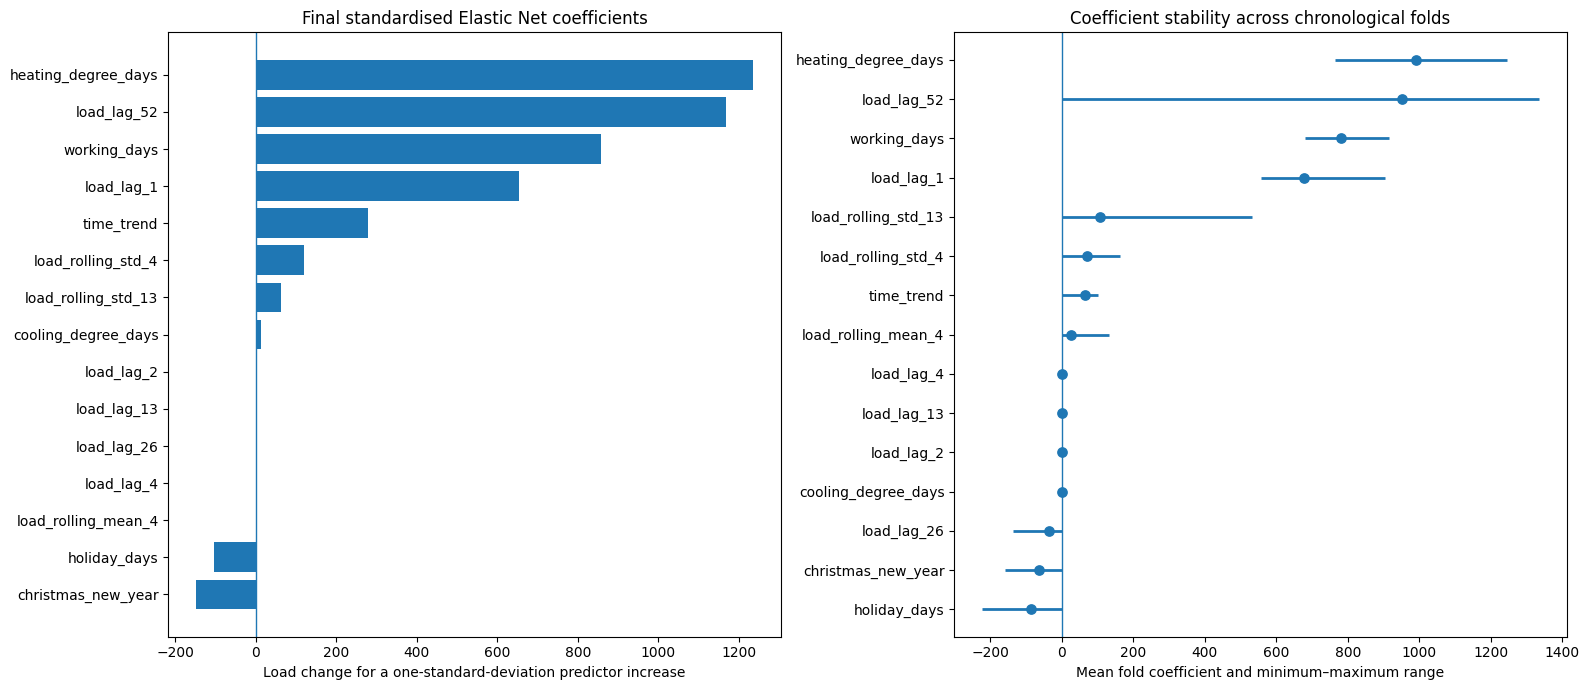

Interpretation warning: coefficients describe regularised predictive associations. They do not prove that a variable causes a change in demand.
A coefficient near zero may indicate limited unique information or overlap with a correlated predictor.


In [6]:
# ============================================================
# CELL 6: ELASTIC NET EXPLAINABILITY AND STABILITY
# ============================================================
# This cell provides the distinctive evidence for Layout 11:
# - Creates a complete feature dictionary
# - Explains forecasting rationale and availability
# - Extracts standardised Elastic Net coefficients
# - Measures coefficient stability across time-series folds
# - Calculates sign consistency
# - Identifies highly correlated engineered predictors
# - Separates predictive association from causal claims
#
# One essential explainability figure is created.
# ============================================================

# ------------------------------------------------------------
# CREATE THE FEATURE DICTIONARY
# ------------------------------------------------------------

feature_information = {
    "load_lag_1": (
        "Load history",
        "Immediate weekly persistence",
        "Positive",
        "Known",
        "Shifted by one week"
    ),

    "load_lag_2": (
        "Load history",
        "Short-term persistence",
        "Positive",
        "Known",
        "Shifted by two weeks"
    ),

    "load_lag_4": (
        "Load history",
        "Approximate monthly recurrence",
        "Positive",
        "Known",
        "Shifted by four weeks"
    ),

    "load_lag_13": (
        "Load history",
        "Quarter-year historical relationship",
        "Positive",
        "Known",
        "Shifted by thirteen weeks"
    ),

    "load_lag_26": (
        "Load history",
        "Half-year relationship",
        "Uncertain",
        "Known",
        "Shifted by twenty-six weeks"
    ),

    "load_lag_52": (
        "Seasonality",
        "Same week in the previous year",
        "Positive",
        "Known",
        "Shifted by fifty-two weeks"
    ),

    "load_rolling_mean_4": (
        "Load level",
        "Recent monthly demand level",
        "Positive",
        "Known",
        "Shifted before rolling"
    ),

    "load_rolling_mean_13": (
        "Load level",
        "Recent quarterly demand level",
        "Positive",
        "Known",
        "Shifted before rolling"
    ),

    "load_rolling_mean_26": (
        "Load level",
        "Medium-term demand level",
        "Positive",
        "Known",
        "Shifted before rolling"
    ),

    "load_rolling_mean_52": (
        "Load level",
        "Long-term annual demand level",
        "Positive",
        "Known",
        "Shifted before rolling"
    ),

    "load_rolling_std_4": (
        "Load variability",
        "Recent short-term volatility",
        "Uncertain",
        "Known",
        "Shifted before rolling"
    ),

    "load_rolling_std_13": (
        "Load variability",
        "Quarterly demand instability",
        "Uncertain",
        "Known",
        "Shifted before rolling"
    ),

    "temperature_mean": (
        "Weather",
        "Current weather-sensitive demand",
        "Nonlinear",
        "Conditional",
        "Observed external variable"
    ),

    "temperature_lag_1": (
        "Weather",
        "Delayed temperature association",
        "Uncertain",
        "Conditional",
        "Shifted by one week"
    ),

    "temperature_rolling_mean_4": (
        "Weather",
        "Persistent recent weather conditions",
        "Uncertain",
        "Conditional",
        "Shifted before rolling"
    ),

    "heating_degree_days": (
        "Weather",
        "Cold-weather demand pressure",
        "Usually positive",
        "Conditional",
        "Observed external variable"
    ),

    "cooling_degree_days": (
        "Weather",
        "Warm-weather cooling demand",
        "Usually positive",
        "Conditional",
        "Observed external variable"
    ),

    "holiday_days": (
        "Calendar",
        "Reduced normal economic activity",
        "Usually negative",
        "Known",
        "Calendar-derived"
    ),

    "working_days": (
        "Calendar",
        "Normal commercial and industrial activity",
        "Usually positive",
        "Known",
        "Calendar-derived"
    ),

    "christmas_new_year": (
        "Calendar",
        "Exceptional festive-period behaviour",
        "Usually negative",
        "Known",
        "Calendar-derived"
    ),

    "week_sine": (
        "Seasonality",
        "Smooth annual seasonal position",
        "Mixed",
        "Known",
        "Calendar-derived"
    ),

    "week_cosine": (
        "Seasonality",
        "Smooth annual seasonal position",
        "Mixed",
        "Known",
        "Calendar-derived"
    ),

    "time_trend": (
        "Trend",
        "Long-term structural movement",
        "Uncertain",
        "Known",
        "Calendar-derived"
    )
}

feature_dictionary = pd.DataFrame([
    {
        "Feature": feature_name,
        "Category": details[0],
        "Forecasting_rationale": details[1],
        "Expected_direction": details[2],
        "Forecast_origin_availability": details[3],
        "Leakage_control": details[4]
    }

    for feature_name, details
    in feature_information.items()
])

feature_dictionary = (
    feature_dictionary
    .set_index("Feature")
    .reindex(elastic_feature_names)
    .reset_index()
)

display(
    feature_dictionary
)

feature_dictionary.to_csv(
    TABLE_DIR / "feature_dictionary.csv",
    index=False
)


# ------------------------------------------------------------
# EXTRACT FINAL STANDARDISED COEFFICIENTS
# ------------------------------------------------------------

final_elastic_coefficients = pd.Series(
    best_elastic_pipeline
    .named_steps[
        "elastic_net"
    ]
    .coef_,
    index=elastic_feature_names,
    name="Final_coefficient"
)

number_nonzero = int(
    np.sum(
        ~np.isclose(
            final_elastic_coefficients,
            0,
            atol=1e-8
        )
    )
)

number_zero = (
    len(final_elastic_coefficients)
    - number_nonzero
)

print(
    "Non-zero Elastic Net coefficients:",
    number_nonzero
)

print(
    "Coefficients reduced to zero:",
    number_zero
)


# ------------------------------------------------------------
# REFIT THE SELECTED MODEL ACROSS CHRONOLOGICAL FOLDS
# ------------------------------------------------------------

fold_coefficient_series = []

for fold_number, (
    fold_train_indices,
    fold_validation_indices
) in enumerate(
    elastic_time_series_cv.split(
        X_elastic_train
    ),
    start=1
):

    fold_pipeline = clone(
        best_elastic_pipeline
    )

    fold_pipeline.fit(
        X_elastic_train.iloc[
            fold_train_indices
        ],

        y_elastic_train.iloc[
            fold_train_indices
        ]
    )

    fold_coefficients = pd.Series(
        fold_pipeline
        .named_steps[
            "elastic_net"
        ]
        .coef_,
        index=elastic_feature_names,
        name=f"Fold_{fold_number}"
    )

    fold_coefficient_series.append(
        fold_coefficients
    )


fold_coefficient_table = pd.concat(
    fold_coefficient_series,
    axis=1
)


def calculate_sign_consistency(values):
    """
    Calculate the largest proportion of folds sharing
    a positive, negative or zero coefficient.
    """

    positive_share = np.mean(
        values > 1e-8
    )

    negative_share = np.mean(
        values < -1e-8
    )

    zero_share = np.mean(
        np.isclose(
            values,
            0,
            atol=1e-8
        )
    )

    return max(
        positive_share,
        negative_share,
        zero_share
    )


coefficient_stability = pd.DataFrame({
    "Final_coefficient": (
        final_elastic_coefficients
    ),

    "Mean_fold_coefficient": (
        fold_coefficient_table
        .mean(axis=1)
    ),

    "Fold_standard_deviation": (
        fold_coefficient_table
        .std(axis=1)
    ),

    "Fold_minimum": (
        fold_coefficient_table
        .min(axis=1)
    ),

    "Fold_maximum": (
        fold_coefficient_table
        .max(axis=1)
    ),

    "Sign_consistency": [
        calculate_sign_consistency(
            fold_coefficient_table.loc[
                feature_name
            ].to_numpy()
        )

        for feature_name
        in fold_coefficient_table.index
    ]
})

coefficient_stability[
    "Absolute_final_coefficient"
] = coefficient_stability[
    "Final_coefficient"
].abs()

coefficient_stability[
    "Direction"
] = np.select(
    [
        coefficient_stability[
            "Final_coefficient"
        ] > 1e-8,

        coefficient_stability[
            "Final_coefficient"
        ] < -1e-8
    ],

    [
        "Positive",
        "Negative"
    ],

    default="Zero"
)

coefficient_stability = (
    coefficient_stability
    .sort_values(
        "Absolute_final_coefficient",
        ascending=False
    )
)

display(
    coefficient_stability.head(15).round(4)
)

coefficient_stability.to_csv(
    TABLE_DIR
    / "elastic_net_coefficient_stability.csv"
)


# ------------------------------------------------------------
# IDENTIFY HIGHLY CORRELATED PREDICTOR PAIRS
# ------------------------------------------------------------

absolute_feature_correlation = (
    X_elastic_train
    .corr()
    .abs()
)

upper_triangle = absolute_feature_correlation.where(
    np.triu(
        np.ones(
            absolute_feature_correlation.shape
        ),
        k=1
    ).astype(bool)
)

high_correlation_rows = []

for column_name in upper_triangle.columns:

    for row_name in upper_triangle.index:

        correlation_value = (
            upper_triangle.loc[
                row_name,
                column_name
            ]
        )

        if (
            pd.notna(correlation_value)
            and correlation_value >= 0.80
        ):

            high_correlation_rows.append({
                "Feature_1": row_name,
                "Feature_2": column_name,
                "Absolute_correlation": (
                    correlation_value
                )
            })


high_correlation_table = (
    pd.DataFrame(
        high_correlation_rows
    )
    .sort_values(
        "Absolute_correlation",
        ascending=False
    )
)

display(
    high_correlation_table.head(15).round(3)
)

high_correlation_table.to_csv(
    TABLE_DIR / "high_feature_correlations.csv",
    index=False
)


# ------------------------------------------------------------
# CREATE THE TOP-COEFFICIENT INTERPRETATION TABLE
# ------------------------------------------------------------

top_interpretation_table = (
    coefficient_stability
    .head(15)
    .reset_index()
    .rename(
        columns={
            "index": "Feature"
        }
    )
    .merge(
        feature_dictionary[
            [
                "Feature",
                "Forecasting_rationale",
                "Forecast_origin_availability"
            ]
        ],
        on="Feature",
        how="left"
    )
)

display(
    top_interpretation_table[
        [
            "Feature",
            "Final_coefficient",
            "Direction",
            "Sign_consistency",
            "Forecasting_rationale",
            "Forecast_origin_availability"
        ]
    ].round(4)
)

top_interpretation_table.to_csv(
    TABLE_DIR
    / "top_elastic_net_coefficient_interpretations.csv",
    index=False
)


# ------------------------------------------------------------
# FIGURE 5: COEFFICIENT DIRECTION AND TEMPORAL STABILITY
# ------------------------------------------------------------

top_features = (
    coefficient_stability
    .head(15)
    .index
)

coefficient_plot_data = (
    coefficient_stability
    .loc[top_features]
    .sort_values(
        "Final_coefficient"
    )
)

stability_plot_data = (
    coefficient_stability
    .loc[top_features]
    .sort_values(
        "Mean_fold_coefficient"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

axes[0].barh(
    coefficient_plot_data.index,
    coefficient_plot_data[
        "Final_coefficient"
    ]
)

axes[0].axvline(
    0,
    linewidth=1
)

axes[0].set_title(
    "Final standardised Elastic Net coefficients"
)

axes[0].set_xlabel(
    "Load change for a one-standard-deviation "
    "predictor increase"
)

y_positions = np.arange(
    len(stability_plot_data)
)

axes[1].hlines(
    y=y_positions,
    xmin=stability_plot_data[
        "Fold_minimum"
    ],
    xmax=stability_plot_data[
        "Fold_maximum"
    ],
    linewidth=2
)

axes[1].scatter(
    stability_plot_data[
        "Mean_fold_coefficient"
    ],
    y_positions,
    s=45
)

axes[1].axvline(
    0,
    linewidth=1
)

axes[1].set_yticks(
    y_positions
)

axes[1].set_yticklabels(
    stability_plot_data.index
)

axes[1].set_title(
    "Coefficient stability across chronological folds"
)

axes[1].set_xlabel(
    "Mean fold coefficient and minimum–maximum range"
)

save_figure(
    "05_elastic_net_coefficients_and_stability.png"
)

print(
    "Interpretation warning: coefficients describe "
    "regularised predictive associations. They do not "
    "prove that a variable causes a change in demand."
)

print(
    "A coefficient near zero may indicate limited unique "
    "information or overlap with a correlated predictor."
)

LSTM tuning training shape: (15336, 168, 1)
LSTM validation shape: (2016, 168, 1)
Training: LSTM_32
Epoch 1/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.4399 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 2/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1837 - val_loss: 0.1241 - learning_rate: 0.0010
Epoch 3/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1639 - val_loss: 0.1066 - learning_rate: 0.0010
Epoch 4/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1529 - val_loss: 0.1008 - learning_rate: 0.0010
Epoch 5/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1418 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 6/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1351 - val_loss: 0.0898 - learning_rate: 0.0010
Epoch 7/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1278 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 8/18
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1203 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 9/18
2

,name,units,dropout,learning_rate,best_epoch,validation_MAE_scaled
1,LSTM_64,[64],0.2,0.0010,17,0.057228
0,LSTM_32,[32],0.1,0.0010,17,0.061598
2,LSTM_64_32,"[64, 32]",0.2,0.0005,16,0.079471


Selected architecture: LSTM_64
Epoch 1/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2149
Epoch 2/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.1353
Epoch 3/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.1174
Epoch 4/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.1078
Epoch 5/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1006
Epoch 6/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0952
Epoch 7/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0922
Epoch 8/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0899
Epoch 9/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0890
Epoch 10/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0867
Epoch 11/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0876
Epoch 12/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0849
Epoch 13/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0845
Epoch 14/17
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0828
Epoch 15/17
511/51

,MAE,RMSE,sMAPE_percent
Hourly Seasonal Naive,2489.796,4294.073,4.606
Hourly LSTM,638.644,869.849,1.185


,MAE,RMSE,sMAPE_percent,MASE,Bias
LSTM Aggregated,136.673,156.691,0.255,0.101,-61.682


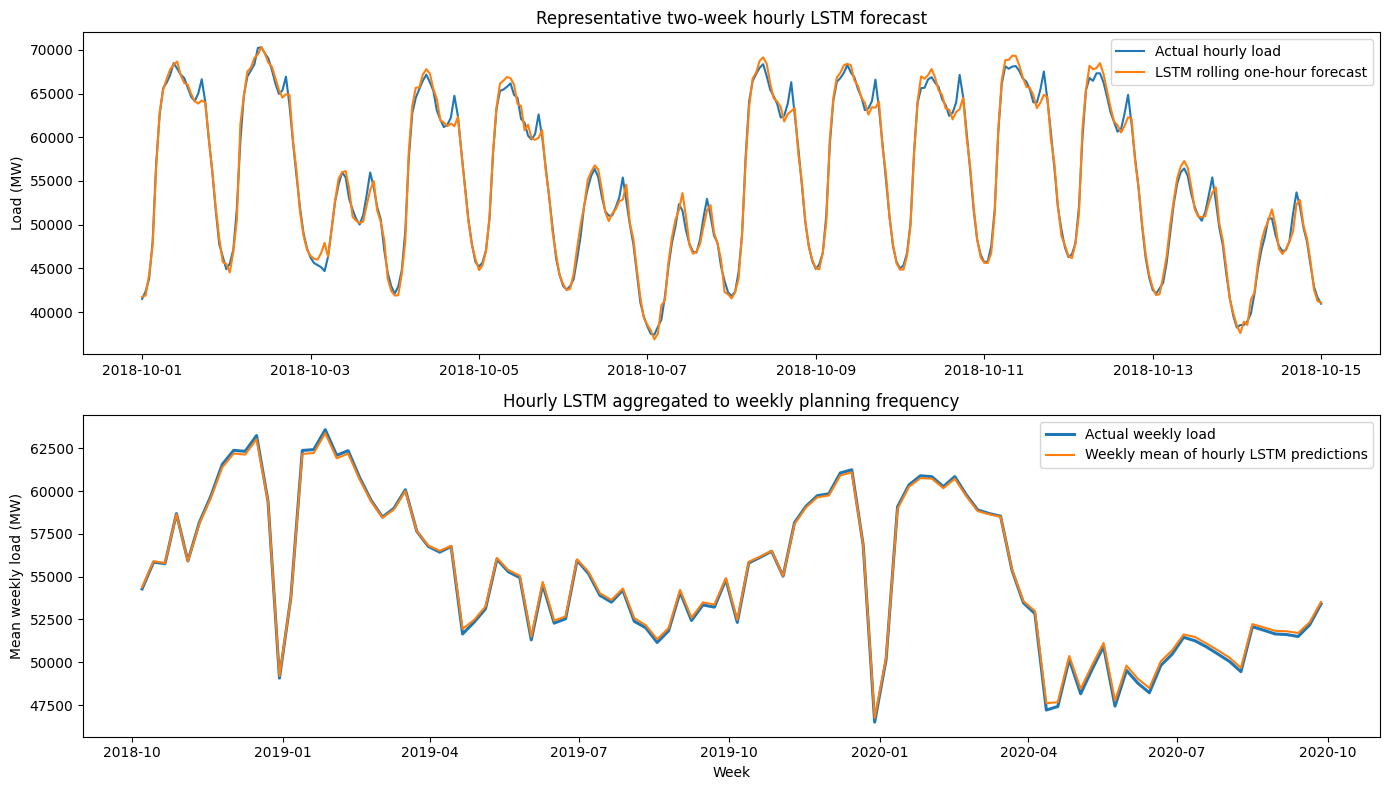

LSTM forecast protocol: rolling one-hour-ahead prediction using the actual latest 168 hours.
This is operational short-term evaluation, not one recursive 104-week hourly forecast from a single origin.


In [7]:
# ============================================================
# CELL 7: HOURLY LSTM TUNING AND FORECASTING
# ============================================================
# This cell completes Assignment Part 6:
# - Uses hourly load data
# - Uses a 168-hour input window
# - Uses chronological training, validation and testing
# - Fits scaling on training observations only
# - Tests compact one-layer and two-layer architectures
# - Uses early stopping and learning-rate reduction
# - Produces rolling one-hour-ahead forecasts
# - Evaluates hourly LSTM against hourly Seasonal Naive
# - Aggregates hourly predictions to weekly means
# - Evaluates aggregated results using weekly metrics
#
# One essential LSTM figure is created.
# ============================================================

import tensorflow as tf

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

LOOKBACK_HOURS = 168
VALIDATION_WEEKS = 12

# Weekly index labels represent Sundays.
# The corresponding first test week begins six days earlier.
hourly_test_start = (
    weekly_test.index.min()
    - pd.Timedelta(days=6)
)

# The final test week ends on the final Sunday.
hourly_test_end_exclusive = (
    weekly_test.index.max()
    + pd.Timedelta(days=1)
)

hourly_validation_start = (
    hourly_test_start
    - pd.Timedelta(
        weeks=VALIDATION_WEEKS
    )
)

hourly_lstm_data = hourly_load.loc[
    :
    hourly_test_end_exclusive
    - pd.Timedelta(hours=1)
].copy()


def create_lstm_sequences(
    scaled_values,
    datetime_index,
    lookback_hours
):
    """
    Create sequences of previous hourly observations
    and the immediately following target.
    """

    X_values = []
    y_values = []
    target_times = []

    for position in range(
        lookback_hours,
        len(scaled_values)
    ):

        X_values.append(
            scaled_values[
                position - lookback_hours:
                position
            ]
        )

        y_values.append(
            scaled_values[
                position,
                0
            ]
        )

        target_times.append(
            datetime_index[position]
        )

    return (
        np.asarray(
            X_values,
            dtype=np.float32
        ),

        np.asarray(
            y_values,
            dtype=np.float32
        ),

        pd.DatetimeIndex(
            target_times
        )
    )


def build_lstm_model(configuration):
    """Build one compact LSTM architecture."""

    model = Sequential()

    model.add(
        Input(
            shape=(
                LOOKBACK_HOURS,
                1
            )
        )
    )

    for layer_number, units in enumerate(
        configuration["units"]
    ):

        return_sequences = (
            layer_number
            < len(
                configuration["units"]
            ) - 1
        )

        model.add(
            LSTM(
                units,
                return_sequences=return_sequences
            )
        )

        model.add(
            Dropout(
                configuration["dropout"]
            )
        )

    model.add(
        Dense(1)
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=configuration[
                "learning_rate"
            ]
        ),
        loss="mae"
    )

    return model


# ------------------------------------------------------------
# TUNING SCALER: FIT BEFORE THE VALIDATION PERIOD
# ------------------------------------------------------------

tuning_scaler = StandardScaler()

tuning_scaler.fit(
    hourly_lstm_data.loc[
        hourly_lstm_data.index
        < hourly_validation_start
    ]
    .to_numpy()
    .reshape(-1, 1)
)

scaled_tuning_values = (
    tuning_scaler
    .transform(
        hourly_lstm_data
        .to_numpy()
        .reshape(-1, 1)
    )
    .astype(np.float32)
)

(
    X_tuning_all,
    y_tuning_all,
    tuning_target_index
) = create_lstm_sequences(
    scaled_tuning_values,
    hourly_lstm_data.index,
    LOOKBACK_HOURS
)

tuning_train_mask = (
    tuning_target_index
    < hourly_validation_start
)

tuning_validation_mask = (
    (
        tuning_target_index
        >= hourly_validation_start
    )
    &
    (
        tuning_target_index
        < hourly_test_start
    )
)

# Every second training sequence is used during tuning
# to reduce runtime without shuffling the chronology.
X_lstm_tuning_train = X_tuning_all[
    tuning_train_mask
][::2]

y_lstm_tuning_train = y_tuning_all[
    tuning_train_mask
][::2]

X_lstm_validation = X_tuning_all[
    tuning_validation_mask
]

y_lstm_validation = y_tuning_all[
    tuning_validation_mask
]

print(
    "LSTM tuning training shape:",
    X_lstm_tuning_train.shape
)

print(
    "LSTM validation shape:",
    X_lstm_validation.shape
)


# ------------------------------------------------------------
# COMPACT ARCHITECTURE SEARCH
# ------------------------------------------------------------

lstm_configurations = [
    {
        "name": "LSTM_32",
        "units": [32],
        "dropout": 0.10,
        "learning_rate": 0.001
    },

    {
        "name": "LSTM_64",
        "units": [64],
        "dropout": 0.20,
        "learning_rate": 0.001
    },

    {
        "name": "LSTM_64_32",
        "units": [64, 32],
        "dropout": 0.20,
        "learning_rate": 0.0005
    }
]

lstm_tuning_rows = []

for configuration in lstm_configurations:

    print(
        "Training:",
        configuration["name"]
    )

    tf.keras.backend.clear_session()

    candidate_model = build_lstm_model(
        configuration
    )

    training_history = candidate_model.fit(
        X_lstm_tuning_train,
        y_lstm_tuning_train,

        validation_data=(
            X_lstm_validation,
            y_lstm_validation
        ),

        epochs=18,
        batch_size=64,

        # Time order must be preserved.
        shuffle=False,

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=2,
                factor=0.5,
                min_lr=1e-5
            )
        ],

        verbose=1
    )

    best_epoch = int(
        np.argmin(
            training_history.history[
                "val_loss"
            ]
        ) + 1
    )

    best_validation_loss = float(
        np.min(
            training_history.history[
                "val_loss"
            ]
        )
    )

    lstm_tuning_rows.append({
        **configuration,
        "best_epoch": best_epoch,
        "validation_MAE_scaled": (
            best_validation_loss
        )
    })


lstm_tuning_table = (
    pd.DataFrame(
        lstm_tuning_rows
    )
    .sort_values(
        "validation_MAE_scaled"
    )
)

display(
    lstm_tuning_table
)

lstm_tuning_table.to_csv(
    TABLE_DIR / "lstm_tuning_results.csv",
    index=False
)

best_lstm_configuration = (
    lstm_tuning_table
    .iloc[0]
    .to_dict()
)

print(
    "Selected architecture:",
    best_lstm_configuration["name"]
)


# ------------------------------------------------------------
# FINAL SCALER: FIT USING ALL PRE-TEST HOURS
# ------------------------------------------------------------

final_lstm_scaler = StandardScaler()

final_lstm_scaler.fit(
    hourly_lstm_data.loc[
        hourly_lstm_data.index
        < hourly_test_start
    ]
    .to_numpy()
    .reshape(-1, 1)
)

scaled_final_values = (
    final_lstm_scaler
    .transform(
        hourly_lstm_data
        .to_numpy()
        .reshape(-1, 1)
    )
    .astype(np.float32)
)

(
    X_final_all,
    y_final_all,
    final_target_index
) = create_lstm_sequences(
    scaled_final_values,
    hourly_lstm_data.index,
    LOOKBACK_HOURS
)

final_train_mask = (
    final_target_index
    < hourly_test_start
)

final_test_mask = (
    (
        final_target_index
        >= hourly_test_start
    )
    &
    (
        final_target_index
        < hourly_test_end_exclusive
    )
)

X_final_train = X_final_all[
    final_train_mask
]

y_final_train = y_final_all[
    final_train_mask
]

X_final_test = X_final_all[
    final_test_mask
]

y_final_test = y_final_all[
    final_test_mask
]

final_test_index = final_target_index[
    final_test_mask
]


selected_configuration = {
    "units": best_lstm_configuration["units"],

    "dropout": float(
        best_lstm_configuration["dropout"]
    ),

    "learning_rate": float(
        best_lstm_configuration[
            "learning_rate"
        ]
    )
}

if isinstance(
    selected_configuration["units"],
    str
):
    selected_configuration[
        "units"
    ] = ast.literal_eval(
        selected_configuration[
            "units"
        ]
    )

final_epochs = max(
    int(
        best_lstm_configuration[
            "best_epoch"
        ]
    ),
    5
)


# ------------------------------------------------------------
# TRAIN THE SELECTED FINAL MODEL
# ------------------------------------------------------------

tf.keras.backend.clear_session()

final_lstm_model = build_lstm_model(
    selected_configuration
)

final_lstm_model.fit(
    X_final_train,
    y_final_train,
    epochs=final_epochs,
    batch_size=64,
    shuffle=False,
    verbose=1
)


# ------------------------------------------------------------
# PRODUCE ROLLING ONE-HOUR-AHEAD PREDICTIONS
# ------------------------------------------------------------

scaled_hourly_prediction = (
    final_lstm_model
    .predict(
        X_final_test,
        batch_size=256,
        verbose=0
    )
)

hourly_prediction_values = (
    final_lstm_scaler
    .inverse_transform(
        scaled_hourly_prediction
    )
    .ravel()
)

hourly_actual_values = (
    final_lstm_scaler
    .inverse_transform(
        y_final_test
        .reshape(-1, 1)
    )
    .ravel()
)

lstm_hourly_prediction = pd.Series(
    hourly_prediction_values,
    index=final_test_index,
    name="LSTM_hourly"
)

lstm_hourly_actual = pd.Series(
    hourly_actual_values,
    index=final_test_index,
    name="Actual_hourly"
)


# ------------------------------------------------------------
# HOURLY SEASONAL-NAIVE BASELINE
# ------------------------------------------------------------

hourly_seasonal_naive = (
    hourly_load
    .shift(168)
    .reindex(
        final_test_index
    )
)

hourly_lstm_metrics = pd.DataFrame({
    "Hourly Seasonal Naive": {
        "MAE": mean_absolute_error(
            lstm_hourly_actual,
            hourly_seasonal_naive
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                lstm_hourly_actual,
                hourly_seasonal_naive
            )
        ),

        "sMAPE_percent": calculate_smape(
            lstm_hourly_actual,
            hourly_seasonal_naive
        )
    },

    "Hourly LSTM": {
        "MAE": mean_absolute_error(
            lstm_hourly_actual,
            lstm_hourly_prediction
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                lstm_hourly_actual,
                lstm_hourly_prediction
            )
        ),

        "sMAPE_percent": calculate_smape(
            lstm_hourly_actual,
            lstm_hourly_prediction
        )
    }
}).T

display(
    hourly_lstm_metrics.round(3)
)


# ------------------------------------------------------------
# AGGREGATE LSTM PREDICTIONS TO WEEKLY MEANS
# ------------------------------------------------------------

lstm_weekly_prediction = (
    lstm_hourly_prediction
    .resample(WEEK_FREQUENCY)
    .mean()
    .reindex(
        weekly_test.index
    )
)

if lstm_weekly_prediction.isna().any():
    raise ValueError(
        "Weekly LSTM predictions are incomplete."
    )

weekly_predictions[
    "LSTM Aggregated"
] = lstm_weekly_prediction

lstm_weekly_metrics = evaluate_forecast(
    weekly_test,
    lstm_weekly_prediction,
    weekly_train
)

display(
    pd.DataFrame(
        [lstm_weekly_metrics],
        index=["LSTM Aggregated"]
    ).round(3)
)

hourly_lstm_metrics.to_csv(
    TABLE_DIR / "hourly_lstm_metrics.csv"
)


# ------------------------------------------------------------
# FIGURE 6: HOURLY AND WEEKLY LSTM EVIDENCE
# ------------------------------------------------------------

sample_end = (
    lstm_hourly_actual.index.min()
    + pd.Timedelta(days=14)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

axes[0].plot(
    lstm_hourly_actual.loc[:sample_end],
    label="Actual hourly load"
)

axes[0].plot(
    lstm_hourly_prediction.loc[:sample_end],
    label="LSTM rolling one-hour forecast"
)

axes[0].set_title(
    "Representative two-week hourly LSTM forecast"
)

axes[0].set_ylabel(
    "Load (MW)"
)

axes[0].legend()

axes[1].plot(
    weekly_test,
    linewidth=2.2,
    label="Actual weekly load"
)

axes[1].plot(
    lstm_weekly_prediction,
    label="Weekly mean of hourly LSTM predictions"
)

axes[1].set_title(
    "Hourly LSTM aggregated to weekly planning frequency"
)

axes[1].set_xlabel("Week")

axes[1].set_ylabel(
    "Mean weekly load (MW)"
)

axes[1].legend()

save_figure(
    "06_lstm_hourly_and_weekly_forecasts.png"
)

print(
    "LSTM forecast protocol: rolling one-hour-ahead "
    "prediction using the actual latest 168 hours."
)

print(
    "This is operational short-term evaluation, not one "
    "recursive 104-week hourly forecast from a single origin."
)

,MAE,RMSE,sMAPE_percent,MASE,Bias,Forecast_type,RMSE_improvement_vs_seasonal_naive_percent,Accuracy_rank
Model,,,,,,,,
LSTM Aggregated,136.673,156.691,0.255,0.101,-61.682,Rolling hourly forecast aggregated weekly,94.756,1
Seasonal Naive,2288.489,2988.248,4.207,1.694,-1747.805,Unconditional annual benchmark,0.000,2
Elastic Net,2744.648,3575.280,5.029,2.031,-2556.569,Recursive load forecast with conditional weather,-19.645,3
SARIMAX,2910.407,3698.229,5.308,2.154,-2815.994,Conditional forecast using observed weather,-23.759,4
SARIMA,3177.990,3912.954,5.758,2.352,-2994.145,Unconditional statistical forecast,-30.945,5
Mean,3789.845,4402.059,6.874,2.805,-561.192,Unconditional benchmark,-47.312,6
Drift,3850.776,4466.494,6.982,2.850,-966.386,Unconditional benchmark,-49.469,7
Naive,3858.148,4475.767,6.995,2.856,-984.534,Unconditional benchmark,-49.779,8


,Model,Season,MAE,Bias
0,Seasonal Naive,Winter,1558.980,-595.905
1,Seasonal Naive,Spring,2972.697,-2302.102
2,Seasonal Naive,Summer,3065.621,-3038.915
3,Seasonal Naive,Autumn,1556.659,-1054.296
4,SARIMA,Winter,2286.373,-1942.722
5,SARIMA,Spring,3818.957,-3488.262
6,SARIMA,Summer,4102.688,-4102.688
7,SARIMA,Autumn,2503.943,-2442.909
8,SARIMAX,Winter,1706.598,-1343.961
9,SARIMAX,Spring,3698.311,-3698.311


,Model,Transparency,Native_uncertainty_interval,Maintenance_requirement,Primary_explanation,RMSE,Accuracy_rank
0,Seasonal Naive,Very high,No,Very low,Repeats the previous annual pattern,2988.248349,2
1,Elastic Net,Very high,No,Low,Standardised coefficients and fold stability,3575.279881,3
2,SARIMAX,High,Yes,Medium,Dynamic coefficients and confidence intervals,3698.228956,4
3,SARIMA,Medium,Yes,Medium,Autoregressive and seasonal dependence,3912.954255,5
4,LSTM Aggregated,Low,No,High,Hidden sequence representation,156.690697,1


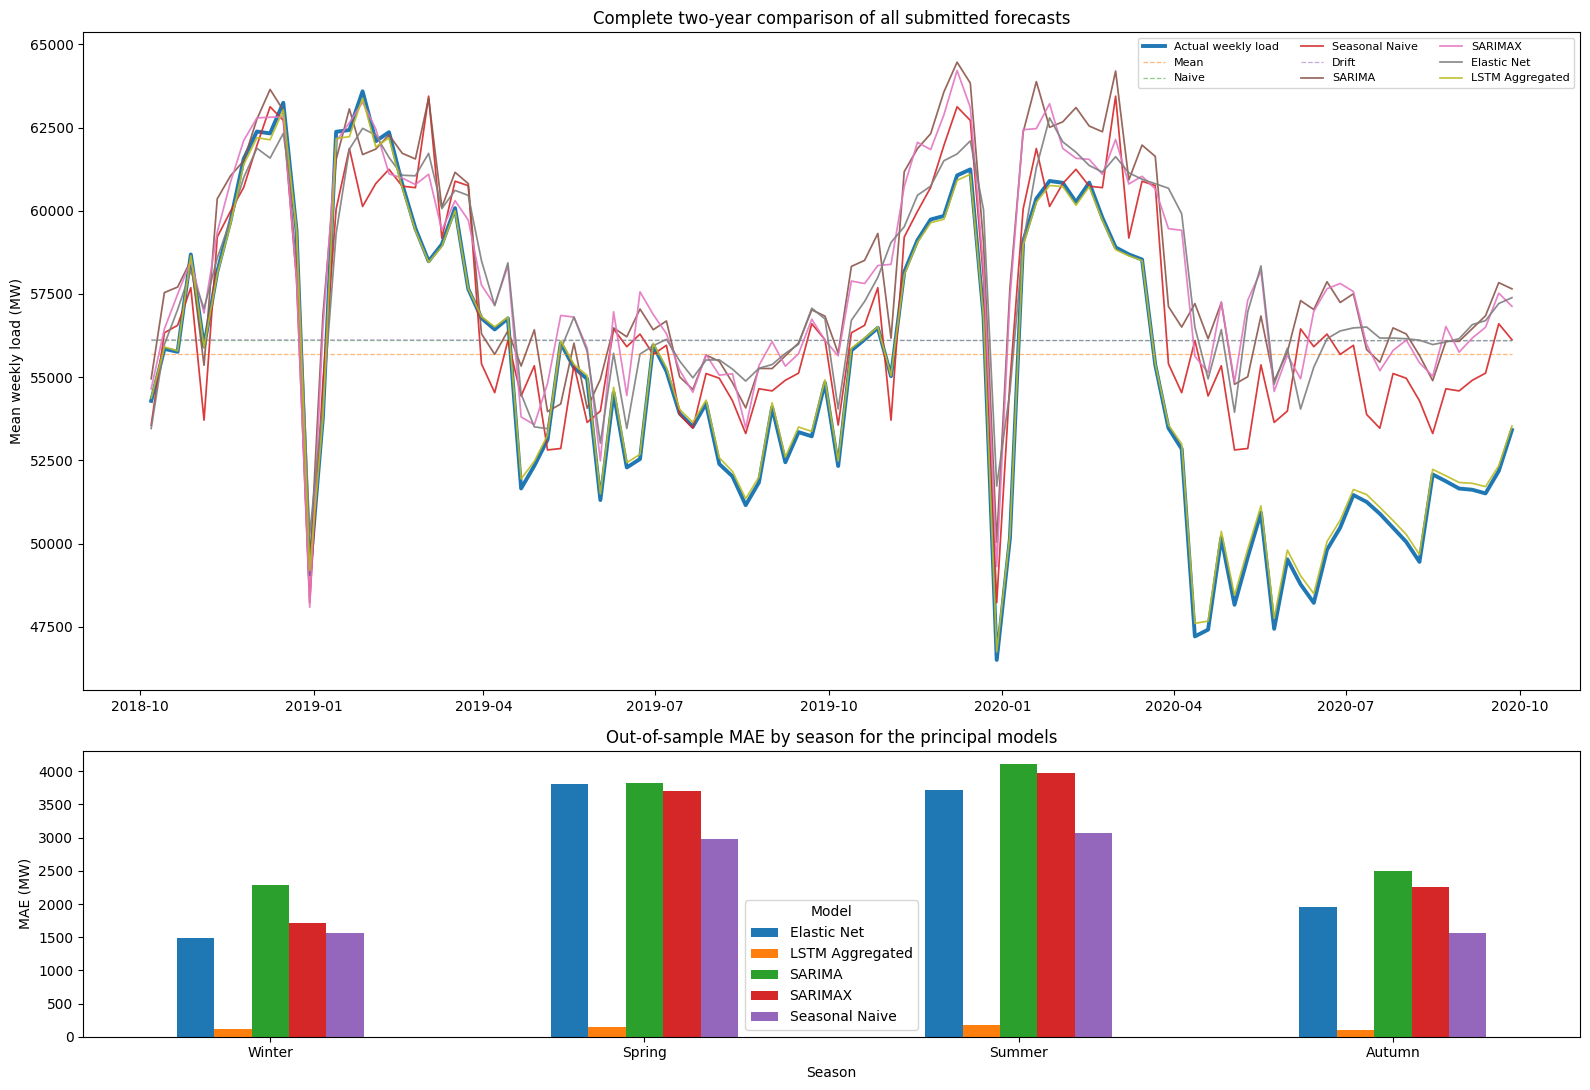

Lowest-RMSE weekly model: LSTM Aggregated
Elastic Net RMSE difference from the best model: 2181.74 %
Mean sign consistency of the five strongest Elastic Net coefficients: 0.92

Operational recommendation rule:
- Prefer Elastic Net when its accuracy is close to the best model and its main coefficients remain stable.
- Prefer SARIMA when uncertainty intervals and low maintenance matter more than a small accuracy gain.
- Use SARIMAX operationally only when suitable future weather inputs are genuinely available.
- Use the LSTM for short-term hourly operation when its accuracy improvement justifies higher maintenance and lower transparency.

All tables and figures are saved in: /content/outputs


In [8]:
# ============================================================
# CELL 8: FINAL MODEL COMPARISON AND DECISION EVIDENCE
# ============================================================
# This cell completes Assignment Parts 7, 8 and supports Part 9:
# - Combines metrics from every model
# - Compares all models with Seasonal Naive
# - Calculates seasonal MAE and bias
# - Compares transparency, uncertainty and maintenance
# - Produces one final plot containing all forecasts
# - Exports predictions, metrics and explainability tables
# - Creates README.md and requirements.txt for GitHub
#
# One essential final figure is created.
# ============================================================

# ------------------------------------------------------------
# CREATE THE FINAL METRICS TABLE
# ------------------------------------------------------------

forecast_type_map = {
    "Mean": (
        "Unconditional benchmark"
    ),

    "Naive": (
        "Unconditional benchmark"
    ),

    "Seasonal Naive": (
        "Unconditional annual benchmark"
    ),

    "Drift": (
        "Unconditional benchmark"
    ),

    "SARIMA": (
        "Unconditional statistical forecast"
    ),

    "SARIMAX": (
        "Conditional forecast using observed weather"
    ),

    "Elastic Net": (
        "Recursive load forecast with conditional weather"
    ),

    "LSTM Aggregated": (
        "Rolling hourly forecast aggregated weekly"
    )
}

final_metric_rows = []

for model_name, model_prediction in (
    weekly_predictions.items()
):

    aligned_prediction = (
        model_prediction
        .reindex(
            weekly_test.index
        )
    )

    if aligned_prediction.isna().any():

        print(
            model_name,
            "was omitted because its predictions "
            "were incomplete."
        )

        continue

    metric_row = evaluate_forecast(
        weekly_test,
        aligned_prediction,
        weekly_train
    )

    metric_row[
        "Model"
    ] = model_name

    metric_row[
        "Forecast_type"
    ] = forecast_type_map.get(
        model_name,
        "Not specified"
    )

    final_metric_rows.append(
        metric_row
    )


final_metrics = (
    pd.DataFrame(
        final_metric_rows
    )
    .set_index("Model")
)

seasonal_naive_rmse = final_metrics.loc[
    "Seasonal Naive",
    "RMSE"
]

final_metrics[
    "RMSE_improvement_vs_seasonal_naive_percent"
] = (
    100
    * (
        seasonal_naive_rmse
        - final_metrics["RMSE"]
    )
    / seasonal_naive_rmse
)

final_metrics[
    "Accuracy_rank"
] = (
    final_metrics["RMSE"]
    .rank(
        method="min"
    )
    .astype(int)
)

final_metrics = (
    final_metrics
    .sort_values("RMSE")
)

display(
    final_metrics.round(3)
)


# ------------------------------------------------------------
# CALCULATE ERRORS BY METEOROLOGICAL SEASON
# ------------------------------------------------------------

def month_to_season(month):
    """Convert month to meteorological season."""

    if month in [
        12,
        1,
        2
    ]:
        return "Winter"

    if month in [
        3,
        4,
        5
    ]:
        return "Spring"

    if month in [
        6,
        7,
        8
    ]:
        return "Summer"

    return "Autumn"


# Weekly labels are Sundays. Thursday is used as the
# representative midpoint of each week.
week_midpoints = (
    weekly_test.index
    - pd.Timedelta(days=3)
)

test_seasons = pd.Series(
    [
        month_to_season(
            date.month
        )

        for date in week_midpoints
    ],

    index=weekly_test.index,
    name="Season"
)

main_comparison_models = [
    "Seasonal Naive",
    "SARIMA",
    "SARIMAX",
    "Elastic Net",
    "LSTM Aggregated"
]

seasonal_error_rows = []

for model_name in main_comparison_models:

    model_prediction = (
        weekly_predictions[
            model_name
        ]
        .reindex(
            weekly_test.index
        )
    )

    for season in [
        "Winter",
        "Spring",
        "Summer",
        "Autumn"
    ]:

        season_mask = (
            test_seasons == season
        )

        seasonal_error_rows.append({
            "Model": model_name,
            "Season": season,

            "MAE": mean_absolute_error(
                weekly_test[
                    season_mask
                ],

                model_prediction[
                    season_mask
                ]
            ),

            "Bias": calculate_bias(
                weekly_test[
                    season_mask
                ],

                model_prediction[
                    season_mask
                ]
            )
        })


seasonal_error_table = pd.DataFrame(
    seasonal_error_rows
)

display(
    seasonal_error_table.round(3)
)


# ------------------------------------------------------------
# CREATE THE TRANSPARENCY–COMPLEXITY TABLE
# ------------------------------------------------------------

transparency_table = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "Elastic Net",
        "SARIMAX",
        "SARIMA",
        "LSTM Aggregated"
    ],

    "Transparency": [
        "Very high",
        "Very high",
        "High",
        "Medium",
        "Low"
    ],

    "Native_uncertainty_interval": [
        "No",
        "No",
        "Yes",
        "Yes",
        "No"
    ],

    "Maintenance_requirement": [
        "Very low",
        "Low",
        "Medium",
        "Medium",
        "High"
    ],

    "Primary_explanation": [
        "Repeats the previous annual pattern",
        "Standardised coefficients and fold stability",
        "Dynamic coefficients and confidence intervals",
        "Autoregressive and seasonal dependence",
        "Hidden sequence representation"
    ]
})

transparency_table = (
    transparency_table
    .merge(
        final_metrics[
            [
                "RMSE",
                "Accuracy_rank"
            ]
        ],
        left_on="Model",
        right_index=True,
        how="left"
    )
)

display(
    transparency_table
)


# ------------------------------------------------------------
# FIGURE 7: ALL FORECASTS AND SEASONAL ERROR
# ------------------------------------------------------------

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

seasonal_mae_pivot = (
    seasonal_error_table
    .pivot(
        index="Season",
        columns="Model",
        values="MAE"
    )
    .reindex(
        season_order
    )
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 11),
    gridspec_kw={
        "height_ratios": [
            2.3,
            1
        ]
    }
)

axes[0].plot(
    weekly_test,
    linewidth=2.8,
    label="Actual weekly load"
)

# Plot every completed assignment model.
for model_name, model_prediction in (
    weekly_predictions.items()
):

    if model_name in final_metrics.index:

        if model_name in [
            "Mean",
            "Naive",
            "Drift"
        ]:

            line_width = 0.9
            line_alpha = 0.55
            line_style = "--"

        else:

            line_width = 1.25
            line_alpha = 0.90
            line_style = "-"

        axes[0].plot(
            model_prediction.reindex(
                weekly_test.index
            ),
            linewidth=line_width,
            alpha=line_alpha,
            linestyle=line_style,
            label=model_name
        )

axes[0].set_title(
    "Complete two-year comparison of all submitted forecasts"
)

axes[0].set_ylabel(
    "Mean weekly load (MW)"
)

axes[0].legend(
    ncol=3,
    fontsize=8
)

seasonal_mae_pivot.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title(
    "Out-of-sample MAE by season for the principal models"
)

axes[1].set_xlabel("Season")

axes[1].set_ylabel(
    "MAE (MW)"
)

axes[1].tick_params(
    axis="x",
    rotation=0
)

save_figure(
    "07_final_forecasts_and_seasonal_errors.png"
)


# ------------------------------------------------------------
# EXPORT ALL FINAL RESULTS
# ------------------------------------------------------------

final_prediction_table = pd.DataFrame({
    "Actual_weekly_load": weekly_test,

    **{
        model_name: prediction.reindex(
            weekly_test.index
        )

        for model_name, prediction
        in weekly_predictions.items()
    }
})

final_metrics.to_csv(
    TABLE_DIR / "final_model_metrics.csv"
)

seasonal_error_table.to_csv(
    TABLE_DIR / "seasonal_model_errors.csv",
    index=False
)

transparency_table.to_csv(
    TABLE_DIR / "transparency_accuracy_comparison.csv",
    index=False
)

final_prediction_table.to_csv(
    TABLE_DIR / "final_weekly_predictions.csv"
)


# ------------------------------------------------------------
# CREATE GITHUB SUPPORT FILES
# ------------------------------------------------------------

requirements_text = """numpy
pandas
matplotlib
scipy
requests
holidays
scikit-learn
statsmodels
tensorflow
"""

Path("requirements.txt").write_text(
    requirements_text,
    encoding="utf-8"
)

readme_text = f"""# Transparent German Electricity-Demand Forecasting

## Project purpose

This repository forecasts German electricity demand using benchmark,
SARIMA, SARIMAX, Elastic Net and LSTM models.

The principal analytical question is whether a transparent regularised
regression model can remain competitive while revealing which historical,
seasonal, weather and calendar predictors influence its forecasts.

## Data

The workflow downloads the Open Power System Data 60-minute time-series
file and selects German actual electricity load from January 2015 onward.

Berlin temperature is retrieved from the Open-Meteo historical archive.

## Forecast design

- Weekly benchmark, SARIMA, SARIMAX and Elastic Net models
- Hourly LSTM model
- Final 104 complete weeks used for testing
- Annual weekly seasonal period: 52
- Training-only scaling
- Time-series cross-validation
- Recursive Elastic Net load forecasting
- Rolling one-hour-ahead LSTM forecasting

## Main outputs

- Data-quality summary
- Stationarity tests
- SARIMA parameter-search results
- Forecast metrics
- SARIMAX coefficients
- Elastic Net feature dictionary
- Elastic Net coefficient-stability table
- Hourly LSTM metrics
- Seasonal forecast errors
- Final combined forecasts

## Run order

Run the eight notebook cells in numerical order.

## Important interpretation

Forecasts using observed test-period temperature are conditional
forecasts. Elastic Net coefficients represent predictive associations,
not causal effects.
"""

Path("README.md").write_text(
    readme_text,
    encoding="utf-8"
)


# ------------------------------------------------------------
# FINAL DECISION EVIDENCE
# ------------------------------------------------------------

best_weekly_model = (
    final_metrics.index[0]
)

best_weekly_rmse = (
    final_metrics.iloc[0]["RMSE"]
)

elastic_net_rmse = (
    final_metrics.loc[
        "Elastic Net",
        "RMSE"
    ]
)

elastic_accuracy_gap = (
    100
    * (
        elastic_net_rmse
        - best_weekly_rmse
    )
    / best_weekly_rmse
)

top_five_stability = (
    coefficient_stability
    .head(5)[
        "Sign_consistency"
    ]
    .mean()
)

print(
    "Lowest-RMSE weekly model:",
    best_weekly_model
)

print(
    "Elastic Net RMSE difference from the best model:",
    round(
        elastic_accuracy_gap,
        2
    ),
    "%"
)

print(
    "Mean sign consistency of the five strongest "
    "Elastic Net coefficients:",
    round(
        top_five_stability,
        3
    )
)

print()
print(
    "Operational recommendation rule:"
)

print(
    "- Prefer Elastic Net when its accuracy is close to "
    "the best model and its main coefficients remain stable."
)

print(
    "- Prefer SARIMA when uncertainty intervals and low "
    "maintenance matter more than a small accuracy gain."
)

print(
    "- Use SARIMAX operationally only when suitable future "
    "weather inputs are genuinely available."
)

print(
    "- Use the LSTM for short-term hourly operation when its "
    "accuracy improvement justifies higher maintenance and "
    "lower transparency."
)

print()
print(
    "All tables and figures are saved in:",
    OUTPUT_DIR.resolve()
)